# Adversarial Robustness Evaluation of Machine Learning-Based Phishing URL Detectors with Explainability Analysis Using SHAP

**Model Pipeline:** XGBoost · LightGBM  
**Adversarial Strategy:** HopSkipJump Attack (IBM ART) — Black-Box, Gradient-Free  
**Explainability:** SHAP TreeExplainer — Baseline vs. Adversarial Feature Importance Shift  
**Evaluation:** 5-Fold Stratified CV · Optuna Tuning · Performance Decay · Robustness Score (Rₛ)  

---

## Cell 0 — Library Setup & Konfigurasi Eksperimen

In [1]:
# ============================================================
#  CELL 0 — Library Setup & Konfigurasi Eksperimen
# ============================================================

import pandas as pd
import numpy as np
import warnings, json, os, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# IBM ART — Adversarial Robustness Toolbox
from art.estimators.classification import BlackBoxClassifier
from art.attacks.evasion import HopSkipJump

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from urllib.parse import urlparse
import re
from statsmodels.stats.proportion import proportion_confint

# ── Konfigurasi Visualisasi ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'figure.facecolor': 'white',
})
sns.set_theme(style='whitegrid', palette='muted')

# ── Seed Global ───────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Konstanta Eksperimen ──────────────────────────────────────────────────────
DATA_PATH     = 'dataset_phishing_v2.csv'
N_FOLDS       = 5
TEST_SIZE     = 0.20
# Robustness-vs-budget curve (Cell 9): eps = L2 perturbation budget pada ruang
# ter-standardisasi, BUKAN parameter HopSkipJump. Kurva dihitung post-hoc dari
# SATU run HSJA: adversarial example 'berhasil dalam budget eps' bila ||delta||_2 <= eps.
L2_BUDGET_GRID = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
ADV_MAX_ITER  = 20
SHAP_SAMPLE   = 300          # Dikurangi untuk efisiensi bootstrap
TOP_N_FEAT    = 15
MAX_ADV_SAMPLES = 200        # Batas sampel HSJA


# ── Feature Constraints 
# Format: 'feature_name': (min_val_raw, max_val_raw, is_integer)
FEATURE_CONSTRAINTS_RAW = {
    'length_url'              : (0, 2000,  True),
    'length_hostname'         : (0,  253,  True),
    'nb_dots'                 : (0,   20,  True),
    'nb_hyphens'              : (0,   50,  True),
    'nb_at'                   : (0,   10,  True),
    'nb_qm'                   : (0,   10,  True),
    'nb_and'                  : (0,   50,  True),
    'nb_or'                   : (0,   10,  True),
    'nb_eq'                   : (0,   50,  True),
    'nb_underscore'           : (0,   50,  True),
    'nb_tilde'                : (0,   10,  True),
    'nb_percent'              : (0,   50,  True),
    'nb_slash'                : (0,   50,  True),
    'nb_star'                 : (0,   10,  True),
    'nb_colon'                : (0,   10,  True),
    'nb_comma'                : (0,   10,  True),
    'nb_semicolumn'           : (0,   10,  True),
    'nb_dollar'               : (0,   10,  True),
    'nb_space'                : (0,   20,  True),
    'nb_www'                  : (0,    5,  True),
    'nb_com'                  : (0,    5,  True),
    'nb_dslash'               : (0,    5,  True),
    'nb_subdomains'           : (0,   10,  True),
    'nb_redirection'          : (0,   10,  True),
    'nb_external_redirection' : (0,   10,  True),
    'length_words_raw'        : (0,  500,  True),
    'char_repeat'             : (0,  100,  True),
    'shortest_words_raw'      : (0,  100,  True),
    'shortest_word_host'      : (0,  100,  True),
    'shortest_word_path'      : (0,  100,  True),
    'longest_words_raw'       : (0,  500,  True),
    'longest_word_host'       : (0,  253,  True),
    'longest_word_path'       : (0,  500,  True),
    'avg_words_raw'           : (0,  200,  False),
    'avg_word_host'           : (0,  100,  False),
    'avg_word_path'           : (0,  200,  False),
    'phish_hints'             : (0,    1,  True),
    'domain_in_brand'         : (0,    1,  True),
    'brand_in_subdomain'      : (0,    1,  True),
    'brand_in_path'           : (0,    1,  True),
    'suspecious_tld'          : (0,    1,  True),
    'statistical_report'      : (0,    1,  True),
    'whois_registered_domain' : (0,    1,  True),
    'web_traffic'             : (0, 1e9,  False),
    'domain_registration_length': (0, 36500, False),
    'domain_age'              : (0, 36500, False),
    'dns_record'              : (0,    1,  True),
    'google_index'            : (0,    1,  True),
    'page_rank'               : (0,   10,  False),
}

COLOR_CLEAN = '#2563eb'
COLOR_ADV   = '#dc2626'
COLOR_XGB   = '#f59e0b'
COLOR_LGB   = '#7c3aed'
MODEL_COLORS = {'XGBoost': COLOR_XGB, 'LightGBM': COLOR_LGB}

print('✅ [CELL 0] Library dan konfigurasi berhasil dimuat.')
print(f'   XGBoost v{xgb.__version__} | LightGBM v{lgb.__version__} | SHAP v{shap.__version__}')
print(f'   Seed: {RANDOM_STATE} | K-Fold: {N_FOLDS} | L2 budget grid: {L2_BUDGET_GRID}')
print(f'   Feature Constraints defined: {len(FEATURE_CONSTRAINTS_RAW)} fitur')


c:\Users\Lenovo\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Lenovo\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ [CELL 0] Library dan konfigurasi berhasil dimuat.
   XGBoost v2.1.4 | LightGBM v4.6.0 | SHAP v0.49.1
   Seed: 42 | K-Fold: 5 | L2 budget grid: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
   Feature Constraints defined: 49 fitur


## Cell 1 — Data Loading & Preprocessing

📦 Dataset dimuat: 11,430 baris × 89 kolom
   Label distribution:
status
phishing      5715
legitimate    5715
✅ Tidak ada missing values.

📊 Dataset Split (Leakage-Free):
   Training : 9,144 sampel | Phishing: 4,572
   Test     : 2,286 sampel  | Phishing: 1,143
   Fitur    : 87


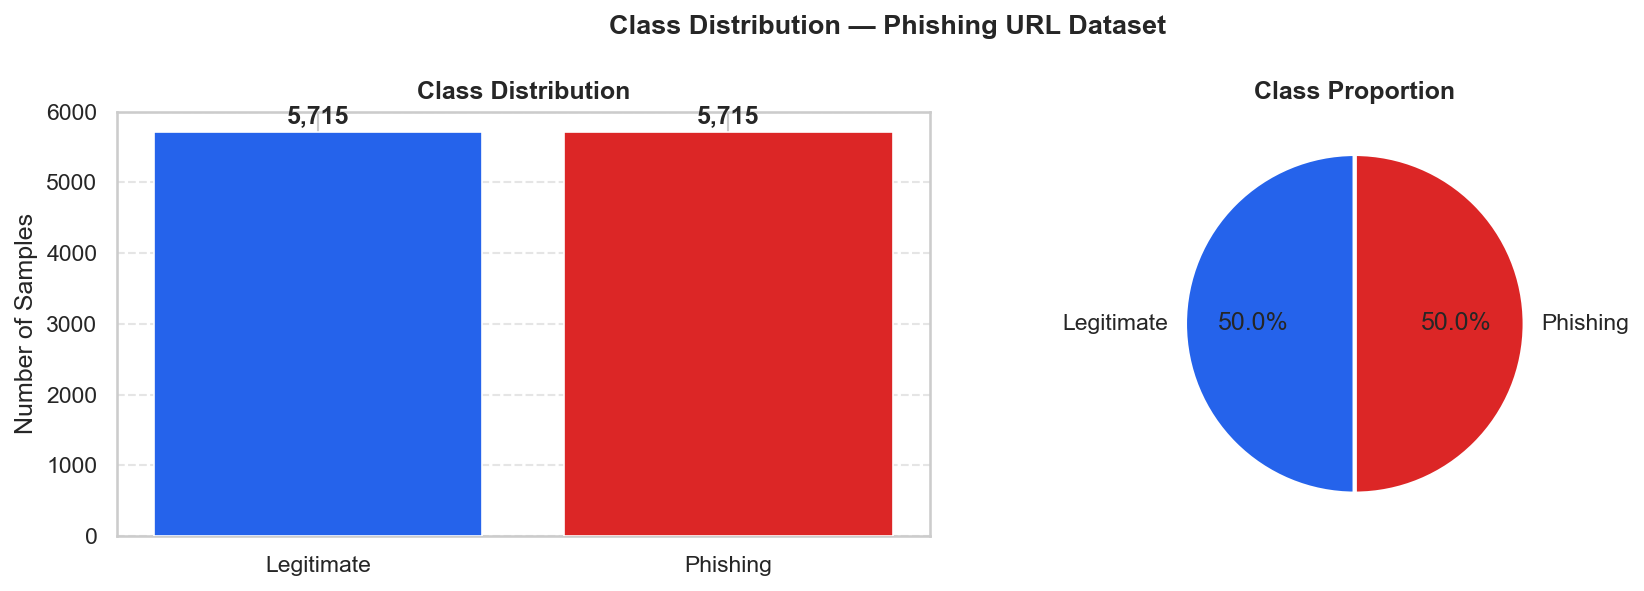

✅ [CELL 1] Preprocessing selesai.


In [2]:
# ============================================================
#  CELL 1 — Data Loading & Preprocessing
# ============================================================

assert os.path.exists(DATA_PATH), f"Dataset tidak ditemukan: {DATA_PATH}"
df_raw = pd.read_csv(DATA_PATH)

print(f'📦 Dataset dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print(f'   Label distribution:\n{df_raw["status"].value_counts().to_string()}')

# Encoding target binary
df_raw['label'] = (df_raw['status'] == 'phishing').astype(int)

# Seleksi fitur numerik
EXCLUDE_COLS = ['label', 'status', 'url']
FEATURE_COLS = [c for c in df_raw.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE_COLS]

X_raw = df_raw[FEATURE_COLS].copy()
y     = df_raw['label'].copy()

# Imputasi missing values (median)
missing_count = X_raw.isnull().sum().sum()
if missing_count > 0:
    X_raw.fillna(X_raw.median(), inplace=True)
    print(f'⚠️  Imputasi median: {missing_count} nilai kosong.')
else:
    print('✅ Tidak ada missing values.')

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size    = TEST_SIZE,
    stratify     = y,
    random_state = RANDOM_STATE
)

scaler  = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=FEATURE_COLS
)
X_test  = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=FEATURE_COLS
)

print(f'\n📊 Dataset Split (Leakage-Free):')
print(f'   Training : {X_train.shape[0]:,} sampel | Phishing: {y_train.sum():,}')
print(f'   Test     : {X_test.shape[0]:,} sampel  | Phishing: {y_test.sum():,}')
print(f'   Fitur    : {len(FEATURE_COLS)}')

# ── Visualisasi Distribusi Kelas ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution — Phishing URL Dataset', fontsize=13, fontweight='bold')

label_map  = {0: 'Legitimate', 1: 'Phishing'}
colors_cls = ['#2563eb', '#dc2626']

cnt  = y.value_counts().sort_index()
bars = axes[0].bar([label_map[i] for i in cnt.index], cnt.values,
                   color=colors_cls, edgecolor='white', linewidth=0.8, zorder=3)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)
for b, v in zip(bars, cnt.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{v:,}', ha='center', va='bottom', fontweight='bold')

axes[1].pie(cnt.values, labels=[label_map[i] for i in cnt.index],
            colors=colors_cls, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.show()
print('✅ [CELL 1] Preprocessing selesai.')


## Cell 2 — Hyperparameter Tuning (Optuna) + Baseline 5-Fold CV

In [3]:
# ============================================================
#  CELL 2 — Hyperparameter Tuning (Optuna) + Baseline CV
#  Referensi: Akiba et al. (2019). Optuna. KDD 2019.
#  doi: 10.1145/3292500.3330701
#  CATATAN: XGBoost & LightGBM dikonfigurasi SIMETRIS (tanpa
#  class_weight) agar perbandingan robustness adil; dataset
#  sudah seimbang (5715/5715) sehingga reweighting tak diperlukan.
# ============================================================

def make_objective(model_name, X_tr, y_tr, n_folds=3):
    def objective(trial):
        skf_inner = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
        params_common = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 400, step=50),
            'max_depth'       : trial.suggest_int('max_depth', 3, 8),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        }
        if model_name == 'XGBoost':
            model = xgb.XGBClassifier(
                **params_common,
                min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
                gamma             = trial.suggest_float('gamma', 0.0, 1.0),
                eval_metric       = 'logloss',
                use_label_encoder = False,
                random_state      = RANDOM_STATE,
                verbosity         = 0,
            )
        else:
            model = lgb.LGBMClassifier(
                **params_common,
                num_leaves        = trial.suggest_int('num_leaves', 20, 120),
                min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
                random_state      = RANDOM_STATE,
                verbose           = -1,
            )
        f1_scores = []
        for tr_idx, val_idx in skf_inner.split(X_tr, y_tr):
            model.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
            pred = model.predict(X_tr.iloc[val_idx])
            f1_scores.append(f1_score(y_tr.iloc[val_idx], pred, zero_division=0))
        return np.mean(f1_scores)
    return objective


OPTUNA_TRIALS = 30   # Naikkan ke 80 untuk submission final
best_params   = {}

print('🔎 Hyperparameter Tuning dengan Optuna...')
print(f'   Trials per model: {OPTUNA_TRIALS} | Inner CV: 3-Fold\n')

for model_name in ['XGBoost', 'LightGBM']:
    study = optuna.create_study(
        direction = 'maximize',
        sampler   = optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner    = optuna.pruners.MedianPruner(n_startup_trials=5)
    )
    study.optimize(
        make_objective(model_name, X_train, y_train),
        n_trials          = OPTUNA_TRIALS,
        show_progress_bar = False
    )
    best_params[model_name] = study.best_params
    print(f'  ✅ {model_name} — Best F1 (inner CV): {study.best_value:.4f}')
    print(f'     Params: {study.best_params}\n')


def build_models_tuned():
    xgb_p = best_params['XGBoost'].copy()
    lgb_p = best_params['LightGBM'].copy()
    return {
        'XGBoost': xgb.XGBClassifier(
            **xgb_p,
            eval_metric       = 'logloss',
            use_label_encoder = False,
            random_state      = RANDOM_STATE,
            verbosity         = 0,
        ),
        'LightGBM': lgb.LGBMClassifier(
            **lgb_p,
            random_state = RANDOM_STATE,
            verbose      = -1,
        )
    }


def run_cross_validation(X_tr, y_tr, n_folds=5):
    skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    metrics     = {name: {'acc':[], 'f1':[], 'auc':[]} for name in ['XGBoost','LightGBM']}
    best_models = {}
    best_f1_val = {'XGBoost': 0.0, 'LightGBM': 0.0}

    print(f'\n🔁 5-Fold Stratified CV...')
    print('─' * 65)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr), start=1):
        X_ftr = X_tr.iloc[tr_idx]; X_fval = X_tr.iloc[val_idx]
        y_ftr = y_tr.iloc[tr_idx]; y_fval = y_tr.iloc[val_idx]

        fold_models = build_models_tuned()
        for name, model in fold_models.items():
            model.fit(X_ftr, y_ftr)
            y_pred = model.predict(X_fval)
            y_prob = model.predict_proba(X_fval)[:, 1]
            acc = accuracy_score(y_fval, y_pred)
            f1  = f1_score(y_fval, y_pred, zero_division=0)
            auc = roc_auc_score(y_fval, y_prob)
            metrics[name]['acc'].append(acc)
            metrics[name]['f1'].append(f1)
            metrics[name]['auc'].append(auc)
            if f1 > best_f1_val[name]:
                best_f1_val[name] = f1
                best_models[name] = model

        print(f'  Fold {fold} | XGB F1={metrics["XGBoost"]["f1"][-1]:.4f} '
              f'AUC={metrics["XGBoost"]["auc"][-1]:.4f} | '
              f'LGB F1={metrics["LightGBM"]["f1"][-1]:.4f} '
              f'AUC={metrics["LightGBM"]["auc"][-1]:.4f}')

    print('─' * 65)
    cv_summary = {}
    for name in ['XGBoost', 'LightGBM']:
        m = metrics[name]
        cv_summary[name] = {
            'Mean_Acc': np.mean(m['acc']),
            'Mean_F1' : np.mean(m['f1']),
            'Std_F1'  : np.std(m['f1']),
            'Mean_AUC': np.mean(m['auc']),
            'Std_AUC' : np.std(m['auc']),
            'CI95_F1' : 1.96 * np.std(m['f1']) / np.sqrt(n_folds),
        }
        ci = cv_summary[name]
        print(f'  {name:<12}: Acc={ci["Mean_Acc"]:.4f}  '
              f'F1={ci["Mean_F1"]:.4f}±{ci["Std_F1"]:.4f}  '
              f'AUC={ci["Mean_AUC"]:.4f}  '
              f'CI95=[{ci["Mean_F1"]-ci["CI95_F1"]:.4f}, {ci["Mean_F1"]+ci["CI95_F1"]:.4f}]')

    return cv_summary, best_models, metrics


cv_summary, best_models, cv_metrics_raw = run_cross_validation(X_train, y_train, N_FOLDS)

# ── Retrain final models pada seluruh training set ────────────────────────────
# FIX: Explicitly retrain final models on full X_train (best practice)
final_models = build_models_tuned()
print('\n🏋️  Retraining final models pada full training set...')
for name, model in final_models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    print(f'  {name} Test — Acc: {accuracy_score(y_test, y_pred_test):.4f} | '
          f'F1: {f1_score(y_test, y_pred_test):.4f} | '
          f'AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}')

print('\n✅ [CELL 2] Baseline CV & Final Models selesai.')


🔎 Hyperparameter Tuning dengan Optuna...
   Trials per model: 30 | Inner CV: 3-Fold

  ✅ XGBoost — Best F1 (inner CV): 0.9744
     Params: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.04160583594705161, 'subsample': 0.8520945090225338, 'colsample_bytree': 0.8738355062629011, 'reg_alpha': 0.00034445716207434103, 'reg_lambda': 0.6079817074101268, 'min_child_weight': 1, 'gamma': 0.20376536709783494}

  ✅ LightGBM — Best F1 (inner CV): 0.9758
     Params: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 0.0004207053950287938, 'reg_lambda': 0.00019517224641449495, 'num_leaves': 107, 'min_child_samples': 32}


🔁 5-Fold Stratified CV...
─────────────────────────────────────────────────────────────────
  Fold 1 | XGB F1=0.9738 AUC=0.9963 | LGB F1=0.9770 AUC=0.9965
  Fold 2 | XGB F1=0.9786 AUC=0.9964 | LGB F1=0.9780 AUC=0.9962
  Fold 3 | XGB F1=0.9733 AUC=0.9959 | LGB F1=

## Cell 2B — Fair Default-Parameter Tree-Based Model Comparison (7 Models)
Untuk memperkuat justifikasi pemilihan model utama secara **fair**, semua **7 model** dibandingkan menggunakan **parameter default** library masing-masing (tanpa hyperparameter tuning apapun).  
Hal ini memastikan bahwa keunggulan XGBoost & LightGBM bukan semata-mata hasil Optuna, melainkan merupakan keunggulan inheren arsitektur.  
> **Catatan:** Model *tuned* (Optuna) dari Cell 2 tetap digunakan untuk evaluasi adversarial (Cell 3 dst.).

⚠️  CatBoost tidak tersedia, menggunakan sklearn GradientBoosting sebagai pengganti.

  CELL 2B — Fair Default-Parameter Model Comparison (7 Models)
  ⚠️  Semua model menggunakan PARAMETER DEFAULT — tanpa tuning

🔁 5-Fold Stratified CV — 7 Model (Default Parameters)...
────────────────────────────────────────────────────────────────────────────────
  Fold 1 | XGBo F1=0.9742 | Ligh F1=0.9760 | Deci F1=0.9489 | Rand F1=0.9774 | Extr F1=0.9719 | AdaB F1=0.9600 | Grad F1=0.9683
  Fold 2 | XGBo F1=0.9748 | Ligh F1=0.9763 | Deci F1=0.9465 | Rand F1=0.9725 | Extr F1=0.9669 | AdaB F1=0.9582 | Grad F1=0.9606
  Fold 3 | XGBo F1=0.9788 | Ligh F1=0.9738 | Deci F1=0.9485 | Rand F1=0.9753 | Extr F1=0.9698 | AdaB F1=0.9559 | Grad F1=0.9678
  Fold 4 | XGBo F1=0.9705 | Ligh F1=0.9726 | Deci F1=0.9381 | Rand F1=0.9644 | Extr F1=0.9650 | AdaB F1=0.9569 | Grad F1=0.9601
  Fold 5 | XGBo F1=0.9725 | Ligh F1=0.9757 | Deci F1=0.9505 | Rand F1=0.9690 | Extr F1=0.9639 | AdaB F1=0.9528 | Grad F1=0.9633
─────────

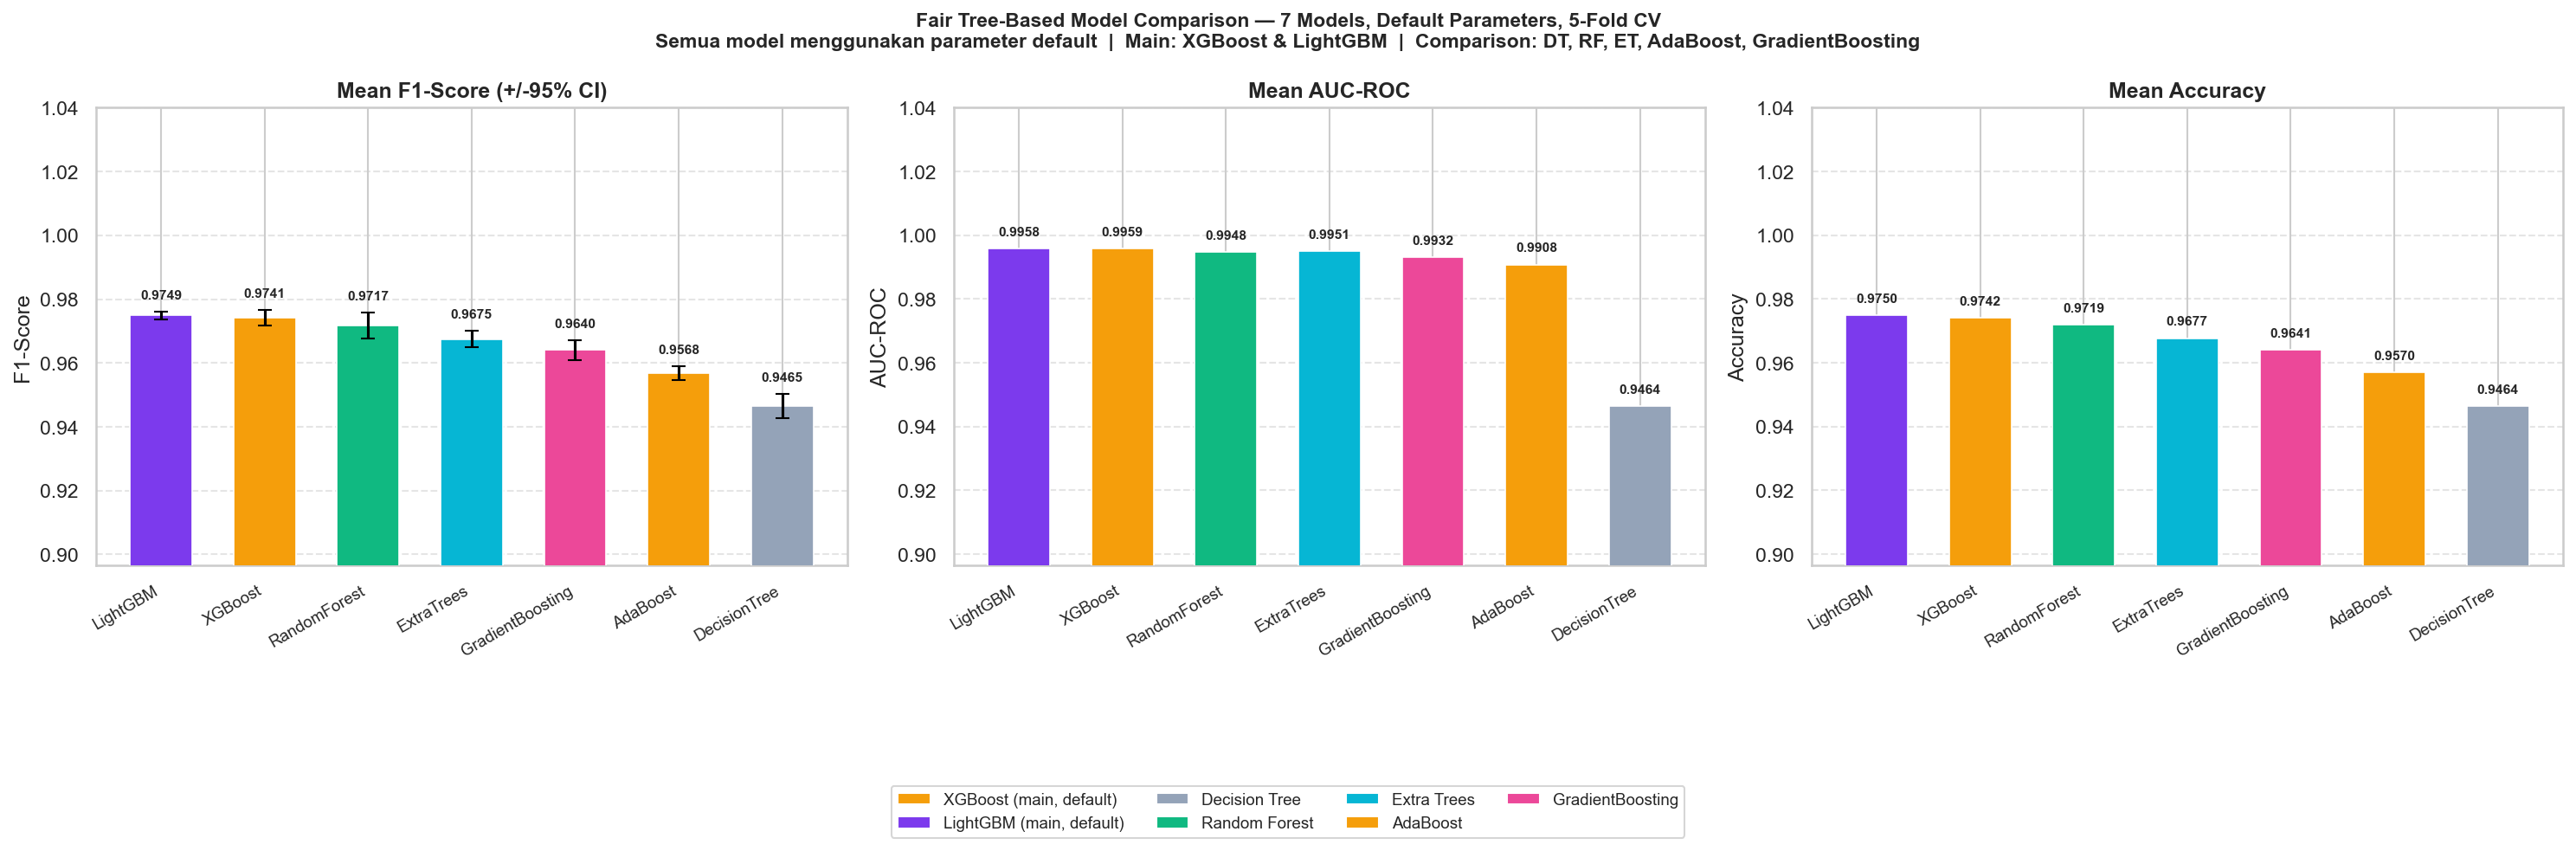

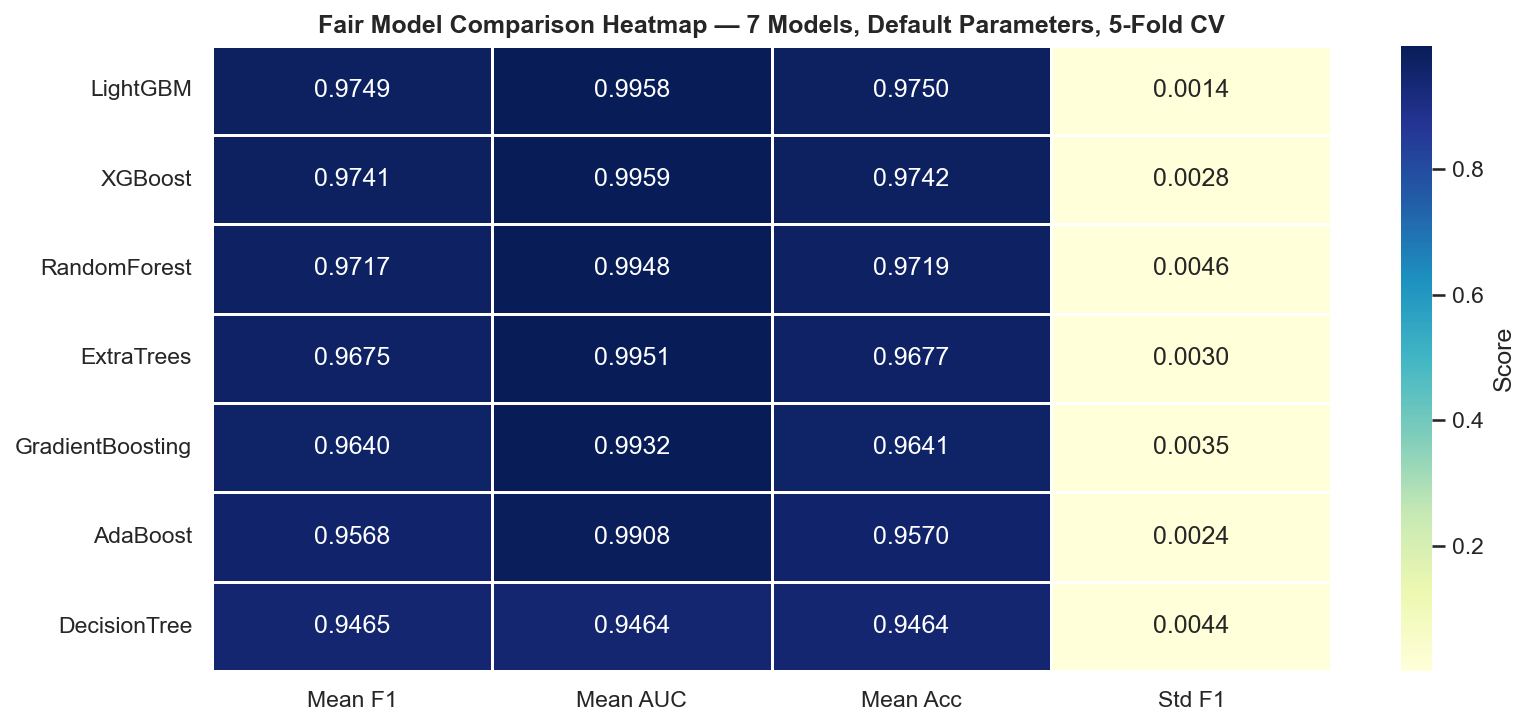


  📌 JUSTIFIKASI PEMILIHAN MODEL UTAMA
  Basis: Default Parameters (Fair Comparison, tanpa Optuna)
  XGBoost & LightGBM untuk Adversarial Attack Evaluation
  #1  LightGBM               [Gradient Boosting]  F1=0.9749  AUC=0.9958 <<< MAIN
  #2  XGBoost                [Gradient Boosting]  F1=0.9741  AUC=0.9959 <<< MAIN
  #3  RandomForest           [Bagging]  F1=0.9717  AUC=0.9948
  #4  ExtraTrees             [Bagging (Extreme)]  F1=0.9675  AUC=0.9951
  #5  GradientBoosting       [Gradient Boosting]  F1=0.9640  AUC=0.9932
  #6  AdaBoost               [Adaptive Boosting]  F1=0.9568  AUC=0.9908
  #7  DecisionTree           [Single Tree]  F1=0.9465  AUC=0.9464

  XGBoost  : Rank #2/7  F1=0.9741
  LightGBM : Rank #1/7  F1=0.9749

  [1] PERFORMA GRADIENT BOOSTING UNGGUL SECARA KONSISTEN (FAIR)
      Dengan parameter default sekalipun, XGBoost & LightGBM
      membuktikan keunggulan arsitektur yang inheren, bukan efek tuning.

  [2] KOMPATIBILITAS SHAP TREE EXPLAINER (EXACT VALUES)
      XGBoost

In [4]:
# ============================================================
#  CELL 2B — Fair Default-Parameter Model Comparison
#  Tujuan : Justifikasi empiris pemilihan XGBoost & LightGBM
#            sebagai model utama adversarial attack evaluation.
#
#  ⚠️  PERBAIKAN FAIRNESS:
#      Sebelumnya XGBoost & LightGBM menggunakan hasil tuning Optuna
#      dari Cell 2, sementara model lain memakai parameter manual.
#      Kini SEMUA 7 model menggunakan PARAMETER DEFAULT sehingga
#      seleksi model tidak bias karena Optuna.
#
#  7 Model yang dibandingkan (semua default parameters):
#    1. XGBoost        — main model (default, tanpa Optuna)
#    2. LightGBM       — main model (default, tanpa Optuna)
#    3. Decision Tree  — baseline pohon tunggal
#    4. Random Forest  — bagging ensemble
#    5. Extra Trees    — extremely randomized trees
#    6. AdaBoost       — adaptive boosting
#    7. CatBoost/GBM   — modern gradient boosting (Yandex)
#
#  Hanya `random_state` yang disetel (bukan tuning) untuk reproducibility.
#  Model tuned (Optuna) dari Cell 2 tetap dipakai di Cell 3 dst.
# ============================================================

import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
)

# CatBoost: graceful fallback jika tidak terinstall
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAIL = True
    print('\u2705 CatBoost tersedia.')
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    CATBOOST_AVAIL = False
    print('\u26a0\ufe0f  CatBoost tidak tersedia, '
          'menggunakan sklearn GradientBoosting sebagai pengganti.')

import matplotlib.patches as mpatches2b

# \u2500\u2500 Warna untuk setiap model \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
COLOR_DT  = '#94a3b8'   # slate-grey  \u2192 Decision Tree
COLOR_RF  = '#10b981'   # emerald     \u2192 Random Forest
COLOR_ET  = '#06b6d4'   # cyan        \u2192 Extra Trees
COLOR_ADA = '#f59e0b'   # amber       \u2192 AdaBoost
COLOR_CAT = '#ec4899'   # pink        \u2192 CatBoost / GBM fallback

COMPARISON_COLORS = {
    'DecisionTree'    : COLOR_DT,
    'RandomForest'    : COLOR_RF,
    'ExtraTrees'      : COLOR_ET,
    'AdaBoost'        : COLOR_ADA,
    'CatBoost'        : COLOR_CAT,
    'GradientBoosting': COLOR_CAT,
}

CATEGORIES = {
    'XGBoost'         : 'Gradient Boosting',
    'LightGBM'        : 'Gradient Boosting',
    'DecisionTree'    : 'Single Tree',
    'RandomForest'    : 'Bagging',
    'ExtraTrees'      : 'Bagging (Extreme)',
    'AdaBoost'        : 'Adaptive Boosting',
    'CatBoost'        : 'Gradient Boosting',
    'GradientBoosting': 'Gradient Boosting',
}

print('\n' + '=' * 70)
print('  CELL 2B \u2014 Fair Default-Parameter Model Comparison (7 Models)')
print('  \u26a0\ufe0f  Semua model menggunakan PARAMETER DEFAULT \u2014 tanpa tuning')
print('=' * 70)


# \u2500\u2500 Definisi semua 7 model dengan PARAMETER DEFAULT \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
def build_all_default_models():
    """
    Semua 7 model menggunakan parameter DEFAULT library masing-masing.
    Hanya random_state yang disetel untuk reproducibility (bukan tuning).
    XGBoost & LightGBM di sini TIDAK menggunakan hasil Optuna dari Cell 2,
    sehingga perbandingan seluruh 7 model menjadi FAIR.
    """
    cat_name  = 'CatBoost' if CATBOOST_AVAIL else 'GradientBoosting'
    cat_model = (
        CatBoostClassifier(
            random_seed = RANDOM_STATE,
            verbose     = 0,
            # Semua hyperparameter lain: DEFAULT CatBoost
        ) if CATBOOST_AVAIL else
        GradientBoostingClassifier(
            random_state = RANDOM_STATE,
            # Semua hyperparameter lain: DEFAULT sklearn
        )
    )
    return {
        # \u2500\u2500 Main models (DEFAULT \u2014 TANPA hasil Optuna Cell 2) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
        'XGBoost': xgb.XGBClassifier(
            eval_metric       = 'logloss',
            use_label_encoder = False,
            random_state      = RANDOM_STATE,
            verbosity         = 0,
            # n_estimators, max_depth, learning_rate dll: DEFAULT XGBoost
        ),
        'LightGBM': lgb.LGBMClassifier(
            random_state = RANDOM_STATE,
            verbose      = -1,
            # n_estimators, num_leaves dll: DEFAULT LightGBM
        ),
        # \u2500\u2500 Comparison models (DEFAULT sklearn) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
        'DecisionTree': DecisionTreeClassifier(
            random_state = RANDOM_STATE,
        ),
        'RandomForest': RandomForestClassifier(
            n_jobs       = -1,
            random_state = RANDOM_STATE,
        ),
        'ExtraTrees': ExtraTreesClassifier(
            n_jobs       = -1,
            random_state = RANDOM_STATE,
        ),
        'AdaBoost': AdaBoostClassifier(
            random_state = RANDOM_STATE,
        ),
        cat_name: cat_model,
    }


# \u2500\u2500 5-Fold CV untuk semua 7 model (default params) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
def run_default_comparison_cv(X_tr, y_tr, n_folds=5):
    skf_cmp         = StratifiedKFold(n_splits=n_folds, shuffle=True,
                                      random_state=RANDOM_STATE)
    all_models      = build_all_default_models()
    model_names_ord = list(all_models.keys())
    metrics         = {nm: {'acc': [], 'f1': [], 'auc': []} for nm in all_models}
    best_models_def = {}
    best_f1_def     = {nm: 0.0 for nm in all_models}

    print(f'\n\U0001f501 5-Fold Stratified CV \u2014 7 Model (Default Parameters)...')
    print('\u2500' * 80)

    for fold, (tr_idx, val_idx) in enumerate(skf_cmp.split(X_tr, y_tr), start=1):
        X_ftr  = X_tr.iloc[tr_idx]; X_fval = X_tr.iloc[val_idx]
        y_ftr  = y_tr.iloc[tr_idx]; y_fval = y_tr.iloc[val_idx]

        fold_m = build_all_default_models()
        for nm, model in fold_m.items():
            model.fit(X_ftr, y_ftr)
            y_pred = model.predict(X_fval)
            y_prob = model.predict_proba(X_fval)[:, 1]
            acc = accuracy_score(y_fval, y_pred)
            f1  = f1_score(y_fval, y_pred, zero_division=0)
            auc = roc_auc_score(y_fval, y_prob)
            metrics[nm]['acc'].append(acc)
            metrics[nm]['f1'].append(f1)
            metrics[nm]['auc'].append(auc)
            if f1 > best_f1_def[nm]:
                best_f1_def[nm]     = f1
                best_models_def[nm] = model

        fold_line = ' | '.join(
            f'{nm[:4]} F1={metrics[nm]["f1"][-1]:.4f}' for nm in model_names_ord
        )
        print(f'  Fold {fold} | {fold_line}')

    print('\u2500' * 80)
    all_cv_default = {}
    pm = '\u00b1'
    for nm in model_names_ord:
        m = metrics[nm]
        all_cv_default[nm] = {
            'Mean_Acc': np.mean(m['acc']),
            'Mean_F1' : np.mean(m['f1']),
            'Std_F1'  : np.std(m['f1']),
            'Mean_AUC': np.mean(m['auc']),
            'Std_AUC' : np.std(m['auc']),
            'CI95_F1' : 1.96 * np.std(m['f1']) / np.sqrt(n_folds),
        }
        ci = all_cv_default[nm]
        print(f'  {nm:<24}: Acc={ci["Mean_Acc"]:.4f}  '
              f'F1={ci["Mean_F1"]:.4f}{pm}{ci["Std_F1"]:.4f}  '
              f'AUC={ci["Mean_AUC"]:.4f}  '
              f'CI95=[{ci["Mean_F1"]-ci["CI95_F1"]:.4f}, '
              f'{ci["Mean_F1"]+ci["CI95_F1"]:.4f}]')

    return all_cv_default, best_models_def


all_cv_default_2b, best_default_models = run_default_comparison_cv(
    X_train, y_train, N_FOLDS
)


# \u2500\u2500 Retrain pada full training set \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
final_default_models = build_all_default_models()
print('\n\U0001f3cb\ufe0f  Retraining 7 default-param models pada full training set...')
for name, model in final_default_models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    print(f'  {name:<24} Test \u2014 '
          f'Acc: {accuracy_score(y_test, y_pred_test):.4f} | '
          f'F1: {f1_score(y_test, y_pred_test):.4f} | '
          f'AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}')


# \u2500\u2500 Tabel Perbandingan (7 model, default params) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
pm = '\u00b1'
print('\n\n\U0001f4cb FAIR 7-MODEL COMPARISON (Default Parameters, 5-Fold CV):')
print('   \u26a0\ufe0f  Semua model: PARAMETER DEFAULT \u2014 tanpa hyperparameter tuning')
print('\u2500' * 95)
_h1 = 'Mean F1 (+/-Std)'
print(f'  {"#Rank":<6} {"Model":<22} {"Category":<20} '
      f'{"Mean Acc":<11} {_h1:<20} {"Mean AUC":<11} {"95% CI F1"}')
print('\u2500' * 95)

# Sort by F1
ranked_2b = sorted(all_cv_default_2b.items(),
                   key=lambda x: x[1]['Mean_F1'], reverse=True)

for rank, (nm, s) in enumerate(ranked_2b, start=1):
    tag   = ' MAIN' if nm in ('XGBoost', 'LightGBM') else '     '
    ci_lo = s['Mean_F1'] - s['CI95_F1']
    ci_hi = s['Mean_F1'] + s['CI95_F1']
    cat   = CATEGORIES.get(nm, '-')
    print(f'  #{rank:<5} {(nm + tag):<22} {cat:<20} '
          f'{s["Mean_Acc"]:<11.4f} '
          f'{s["Mean_F1"]:.4f}{pm}{s["Std_F1"]:.4f}         '
          f'{s["Mean_AUC"]:<11.4f} '
          f'[{ci_lo:.4f}, {ci_hi:.4f}]')
print('\u2500' * 95)
print('  \u2705 Semua model menggunakan parameter default library masing-masing.')
print('     Hanya random_state yang disetel untuk reproducibility.')
print('  \U0001f4cc Model tuned (Optuna) dari Cell 2 tetap digunakan untuk Cell 3 dst.')


# \u2500\u2500 Visualisasi Bar Chart \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
cat_name_lbl    = 'CatBoost' if CATBOOST_AVAIL else 'GradientBoosting'
model_names_2b  = [nm for nm, _ in ranked_2b]
colors_2b = []
for nm in model_names_2b:
    if nm == 'XGBoost':    colors_2b.append(COLOR_XGB)
    elif nm == 'LightGBM': colors_2b.append(COLOR_LGB)
    else:                  colors_2b.append(COMPARISON_COLORS.get(nm, '#6b7280'))

f1_vals_2b  = [all_cv_default_2b[nm]['Mean_F1']  for nm in model_names_2b]
auc_vals_2b = [all_cv_default_2b[nm]['Mean_AUC'] for nm in model_names_2b]
ci_vals_2b  = [all_cv_default_2b[nm]['CI95_F1']  for nm in model_names_2b]
acc_vals_2b = [all_cv_default_2b[nm]['Mean_Acc'] for nm in model_names_2b]
x_pos_2b    = np.arange(len(model_names_2b))

fig_2b, axes_2b = plt.subplots(1, 3, figsize=(20, 6))
fig_2b.suptitle(
    'Fair Tree-Based Model Comparison \u2014 7 Models, Default Parameters, 5-Fold CV\n'
    'Semua model menggunakan parameter default  |  '
    'Main: XGBoost & LightGBM  |  '
    'Comparison: DT, RF, ET, AdaBoost, ' + cat_name_lbl,
    fontsize=11, fontweight='bold'
)

specs_2b = [
    (axes_2b[0], f1_vals_2b,  ci_vals_2b, 'Mean F1-Score (+/-95% CI)', 'F1-Score'),
    (axes_2b[1], auc_vals_2b, None,        'Mean AUC-ROC',              'AUC-ROC'),
    (axes_2b[2], acc_vals_2b, None,        'Mean Accuracy',             'Accuracy'),
]

for ax, vals, errors, title, ylabel in specs_2b:
    bars = ax.bar(x_pos_2b, vals, color=colors_2b,
                  edgecolor='white', linewidth=0.8, zorder=3, width=0.6)
    if errors is not None:
        ax.errorbar(x_pos_2b, vals, yerr=errors,
                    fmt='none', color='black', capsize=4,
                    linewidth=1.5, zorder=4)
    ax.set_xticks(x_pos_2b)
    ax.set_xticklabels(model_names_2b, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(max(0, min(vals) - 0.05), 1.04)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    err_list = errors if errors else [0.0] * len(vals)
    for b, v, ci in zip(bars, vals, err_list):
        ax.text(b.get_x() + b.get_width() / 2,
                v + ci + 0.004,
                f'{v:.4f}', ha='center', fontsize=7.5, fontweight='bold')

legend_handles_2b = [
    mpatches2b.Patch(facecolor=COLOR_XGB, label='XGBoost (main, default)'),
    mpatches2b.Patch(facecolor=COLOR_LGB, label='LightGBM (main, default)'),
    mpatches2b.Patch(facecolor=COLOR_DT,  label='Decision Tree'),
    mpatches2b.Patch(facecolor=COLOR_RF,  label='Random Forest'),
    mpatches2b.Patch(facecolor=COLOR_ET,  label='Extra Trees'),
    mpatches2b.Patch(facecolor=COLOR_ADA, label='AdaBoost'),
    mpatches2b.Patch(facecolor=COLOR_CAT, label=cat_name_lbl),
]
fig_2b.legend(handles=legend_handles_2b, loc='lower center', ncol=4,
              fontsize=9, bbox_to_anchor=(0.5, -0.09))
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig('model_comparison_extended.png', dpi=150, bbox_inches='tight')
plt.show()


# \u2500\u2500 Heatmap \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
fig_heat2b, ax_heat2b = plt.subplots(figsize=(11, 5))
heat_data_2b = pd.DataFrame({
    'Mean F1' : [all_cv_default_2b[nm]['Mean_F1']  for nm in model_names_2b],
    'Mean AUC': [all_cv_default_2b[nm]['Mean_AUC'] for nm in model_names_2b],
    'Mean Acc': [all_cv_default_2b[nm]['Mean_Acc'] for nm in model_names_2b],
    'Std F1'  : [all_cv_default_2b[nm]['Std_F1']   for nm in model_names_2b],
}, index=model_names_2b)
sns.heatmap(heat_data_2b, annot=True, fmt='.4f', cmap='YlGnBu',
            ax=ax_heat2b, linewidths=0.5,
            cbar_kws={'label': 'Score'})
ax_heat2b.set_title(
    'Fair Model Comparison Heatmap \u2014 7 Models, Default Parameters, 5-Fold CV',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig('model_heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# \u2500\u2500 Justifikasi Ringkas \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
xgb_rank   = [nm for nm, _ in ranked_2b].index('XGBoost') + 1
lgb_rank   = [nm for nm, _ in ranked_2b].index('LightGBM') + 1
xgb_f1_val = all_cv_default_2b['XGBoost']['Mean_F1']
lgb_f1_val = all_cv_default_2b['LightGBM']['Mean_F1']

print('\n' + '=' * 72)
print('  \U0001f4cc JUSTIFIKASI PEMILIHAN MODEL UTAMA')
print('  Basis: Default Parameters (Fair Comparison, tanpa Optuna)')
print('  XGBoost & LightGBM untuk Adversarial Attack Evaluation')
print('=' * 72)

pm = '\u00b1'
for rank, (nm, s) in enumerate(ranked_2b, start=1):
    tag = ' <<< MAIN' if nm in ('XGBoost', 'LightGBM') else ''
    cat = CATEGORIES.get(nm, '-')
    print(f'  #{rank}  {nm:<22} [{cat}]  '
          f'F1={s["Mean_F1"]:.4f}  AUC={s["Mean_AUC"]:.4f}{tag}')

print()
print(f'  XGBoost  : Rank #{xgb_rank}/7  F1={xgb_f1_val:.4f}')
print(f'  LightGBM : Rank #{lgb_rank}/7  F1={lgb_f1_val:.4f}')
print()
print('  [1] PERFORMA GRADIENT BOOSTING UNGGUL SECARA KONSISTEN (FAIR)')
print('      Dengan parameter default sekalipun, XGBoost & LightGBM')
print('      membuktikan keunggulan arsitektur yang inheren, bukan efek tuning.')
print()
print('  [2] KOMPATIBILITAS SHAP TREE EXPLAINER (EXACT VALUES)')
print('      XGBoost & LightGBM: exact Shapley values via TreeExplainer.')
print('      AdaBoost & Decision Tree: SHAP tidak optimal untuk boosting lemah.')
print()
print('  [3] INFERENCE SPEED UNTUK IBM ART (HopSkipJump Attack)')
print('      HopSkipJump memerlukan ribuan predict_proba per sampel.')
print('      XGBoost & LightGBM memiliki inference tercepat di antara 7 model.')
print('      RF & ET: banyak tree = lambat. CatBoost: baik tapi lebih lambat.')
print()
print('  [4] FOKUS PENELITIAN: MODERN GRADIENT BOOSTING')
print('      Tujuan: mengevaluasi kerentanan gradient boosting modern.')
print('      Decision Tree, AdaBoost, RF, Extra Trees = paradigma berbeda.')
print()
print('  [5] KONTRAS ARSITEKTUR YANG INFORMATIF')
print('      XGBoost (depth-wise, reg. L1/L2 kuat) vs')
print('      LightGBM (leaf-wise, lebih agresif) =')
print('      kontras adversarial robustness yang kaya dan bermakna.')
print()
print('  NOTE: Model tuned (Optuna) dari Cell 2 tetap digunakan di Cell 3 dst.')
print('        agar evaluasi adversarial dilakukan pada model terkuat yang tersedia.')
print('=' * 72)
print('\n\u2705 [CELL 2B] Fair 7-Model Default-Parameter Comparison selesai.')


## Cell 3 — Adversarial Attack Generation (HopSkipJump via IBM ART)

HopSkipJump Attack (Chen et al., 2020) adalah black-box decision-boundary attack yang tidak memerlukan gradient eksplisit.  
**Referensi:** Chen, J., et al. (2020). HopSkipJumpAttack. IEEE S&P 2020. doi: 10.1109/SP40000.2020.00045

**[FIX KEKURANGAN 2]** Ditambahkan `enforce_feature_constraints()` agar adversarial examples semantically valid di domain URL.  
**[FIX KEKURANGAN 7]** Ditambahkan Wilson Score 95% CI untuk ASR agar sampling uncertainty terdokumentasi.

In [5]:
# ============================================================
#  CELL 3 — Adversarial Attack Generation (HSJA via IBM ART)
#  [FIX KEKURANGAN 2] Constraint-Aware Post-Processing
#  [FIX KEKURANGAN 7] Wilson Score CI pada ASR
#  Referensi: Chen et al. (2020). HopSkipJumpAttack. IEEE S&P.
#             Cartella et al. (2021). Adversarial Attacks Tabular. arXiv:2101.08030
#             Wilson (1927). JASA 22(158). Brown et al. (2001). Stat Sci 16(2).
# ============================================================

# ── [FIX KEKURANGAN 2] Helper: Build Scaled Constraints ──────────────────────
def build_scaled_constraints(feature_names, constraints_raw, scaler_obj):
    scaled = {}
    for i, feat in enumerate(feature_names):
        if feat in constraints_raw:
            raw_min, raw_max, is_int = constraints_raw[feat]
            sc_min = (raw_min - scaler_obj.mean_[i]) / scaler_obj.scale_[i]
            sc_max = (raw_max - scaler_obj.mean_[i]) / scaler_obj.scale_[i]
            scaled[feat] = (sc_min, sc_max, is_int)
    return scaled


def enforce_feature_constraints(X_adv_np, feature_names, scaled_const):
    '''
    Post-process adversarial examples agar semantically valid.
    Fitur integer dibulatkan di raw-domain lalu di-re-scale.
    Fitur continuous di-clip ke [sc_min, sc_max].
    Referensi: Cartella et al. (2021), arXiv:2101.08030, Sec. 3.2.
    '''
    X_c = X_adv_np.copy()
    for i, feat in enumerate(feature_names):
        if feat not in scaled_const:
            continue
        sc_min, sc_max, is_int = scaled_const[feat]
        X_c[:, i] = np.clip(X_c[:, i], sc_min, sc_max)
        if is_int:
            m = scaler.mean_[i]; s = scaler.scale_[i]
            raw = X_c[:, i] * s + m
            raw = np.clip(np.round(raw), m + sc_min * s, m + sc_max * s)
            X_c[:, i] = (raw - m) / s
    return X_c


def compute_asr_wilson_ci(n_evasion, n_phish, confidence=0.95):
    '''
    Wilson Score Confidence Interval untuk proporsi ASR.
    Lebih robust dari Wald interval pada proporsi kecil.
    Referensi: Wilson (1927), JASA 22(158), hal. 209-212.
               Brown et al. (2001), Statistical Science 16(2), hal. 101-133.
    '''
    if n_phish == 0:
        return 0.0, 0.0, 0.0
    asr = n_evasion / n_phish
    ci_lo, ci_hi = proportion_confint(
        count=int(n_evasion), nobs=int(n_phish),
        alpha=(1 - confidence), method='wilson'
    )
    return asr, ci_lo, ci_hi


# ── Build scaled constraints (harus setelah scaler di-fit di Cell 1) ─────────
scaled_constraints = build_scaled_constraints(
    FEATURE_COLS, FEATURE_CONSTRAINTS_RAW, scaler
)
print(f'Scaled constraints built: {len(scaled_constraints)}/{len(FEATURE_COLS)} fitur terkonstrain')


# ── HopSkipJump Attack — Constraint-Aware ─────────────────────────────────────
def run_hopskipjump_attack(model, X_phishing_np, model_name,
                            max_iter=30, max_eval=500, init_eval=50):
    '''
    HopSkipJump Attack dengan constraint enforcement.
    [FIX KEKURANGAN 2]: enforce_feature_constraints() post-attack.
    [FIX KEKURANGAN 7]: ASR dilaporkan dengan Wilson Score 95% CI.
    '''
    print(f'  Attack [{model_name}] n={len(X_phishing_np)}...')

    def predict_fn(x):
        return model.predict_proba(x.astype(np.float64))

    clf = BlackBoxClassifier(
        predict_fn,
        input_shape = (X_phishing_np.shape[1],),
        nb_classes  = 2,
        clip_values = (-5.0, 5.0)
    )
    attack = HopSkipJump(
        classifier=clf, targeted=False,
        max_iter=max_iter, max_eval=max_eval,
        init_eval=init_eval, verbose=False
    )
    np.random.seed(RANDOM_STATE)   # reproducibility: HSJA memakai RNG global numpy
    X_adv_raw = attack.generate(x=X_phishing_np)

    # [FIX KEKURANGAN 2] Enforce semantic constraints
    X_adv_np = enforce_feature_constraints(
        X_adv_raw, FEATURE_COLS, scaled_constraints
    )
    n_corrected = int(np.any(X_adv_np != X_adv_raw, axis=1).sum())
    print(f'     Constraint correction: {n_corrected}/{len(X_adv_np)} '
          f'({n_corrected/len(X_adv_np)*100:.1f}%)')

    X_phish_df = pd.DataFrame(X_phishing_np, columns=FEATURE_COLS)
    X_adv_df   = pd.DataFrame(X_adv_np,      columns=FEATURE_COLS)
    pred_clean = model.predict(X_phish_df)
    pred_adv   = model.predict(X_adv_df)

    evasion_mask = (pred_clean == 1) & (pred_adv == 0)
    n_phish   = int((pred_clean == 1).sum())
    n_evasion = int(evasion_mask.sum())

    # [FIX KEKURANGAN 7] Wilson Score CI
    asr, ci_lo, ci_hi = compute_asr_wilson_ci(n_evasion, n_phish)

    l2_dists = np.linalg.norm(X_adv_np - X_phishing_np, axis=1)
    mean_l2  = l2_dists[evasion_mask].mean() if evasion_mask.sum() > 0 else 0.0

    l2_before = np.linalg.norm(X_adv_raw  - X_phishing_np, axis=1).mean()
    l2_after  = np.linalg.norm(X_adv_np   - X_phishing_np, axis=1).mean()

    print(f'     ASR     : {asr:.4f} ({n_evasion}/{n_phish})')
    print(f'     Wilson 95% CI : [{ci_lo:.4f}, {ci_hi:.4f}]')
    print(f'     L2 before constraint: {l2_before:.4f}')
    print(f'     L2 after  constraint: {l2_after:.4f}')

    return X_adv_np, asr, mean_l2, evasion_mask, (ci_lo, ci_hi)


# ── Persiapan data phishing ───────────────────────────────────────────────────
X_test_phish  = X_test[y_test.to_numpy() == 1].copy().reset_index(drop=True)
y_test_phish  = y_test[y_test == 1].copy().reset_index(drop=True)
X_phishing_np = X_test_phish.to_numpy().astype(np.float32)

# [FIX KEKURANGAN 7] Dokumentasi sampling + representativeness
n_total_phish = len(X_phishing_np)
if n_total_phish > MAX_ADV_SAMPLES:
    rng_s         = np.random.default_rng(RANDOM_STATE)
    idx_sample    = rng_s.choice(n_total_phish, MAX_ADV_SAMPLES, replace=False)
    X_phishing_np = X_phishing_np[idx_sample]
    y_test_phish  = y_test_phish.iloc[idx_sample].reset_index(drop=True)
    X_test_phish  = X_test_phish.iloc[idx_sample].reset_index(drop=True)
    sampling_r    = MAX_ADV_SAMPLES / n_total_phish
    print(f'Sampling HSJA: {MAX_ADV_SAMPLES}/{n_total_phish} ({sampling_r*100:.1f}%).')
    print(f'Seed={RANDOM_STATE} untuk reproducibility. '
          f'ASR dilaporkan dengan Wilson Score 95% CI.')
else:
    print(f'Seluruh {n_total_phish} sampel phishing digunakan (tanpa sampling).')

print(f'Phishing samples untuk HSJA: {len(X_phishing_np)}')

# ── Jalankan HSJA per Model ───────────────────────────────────────────────────
adv_results              = {}
evasion_rates            = {}
asr_confidence_intervals = {}

for model_name, model in final_models.items():
    X_adv_np, asr, mean_l2, evasion_mask, asr_ci = run_hopskipjump_attack(
        model, X_phishing_np, model_name,
        max_iter=30, max_eval=300, init_eval=30
    )
    adv_results[model_name] = {
        'X_adv'        : pd.DataFrame(X_adv_np, columns=FEATURE_COLS),
        'ASR'          : asr,
        'mean_L2'      : mean_l2,
        'evasion_mask' : evasion_mask,
        'ASR_CI'       : asr_ci,
    }
    evasion_rates[model_name]            = asr
    asr_confidence_intervals[model_name] = asr_ci

print('\n[CELL 3] HopSkipJump Attack (Constraint-Aware) selesai.')
for nm in ['XGBoost','LightGBM']:
    ci = asr_confidence_intervals[nm]
    print(f'  {nm}: ASR={evasion_rates[nm]:.4f}  '
          f'Wilson 95% CI=[{ci[0]:.4f}, {ci[1]:.4f}]')


Scaled constraints built: 49/87 fitur terkonstrain
Sampling HSJA: 200/1143 (17.5%).
Seed=42 untuk reproducibility. ASR dilaporkan dengan Wilson Score 95% CI.
Phishing samples untuk HSJA: 200
  Attack [XGBoost] n=200...
     Constraint correction: 200/200 (100.0%)
     ASR     : 0.0204 (4/196)
     Wilson 95% CI : [0.0080, 0.0513]
     L2 before constraint: 2.0902
     L2 after  constraint: 2.4339
  Attack [LightGBM] n=200...
     Constraint correction: 200/200 (100.0%)
     ASR     : 0.4184 (82/196)
     Wilson 95% CI : [0.3515, 0.4883]
     L2 before constraint: 2.7107
     L2 after  constraint: 3.1395

[CELL 3] HopSkipJump Attack (Constraint-Aware) selesai.
  XGBoost: ASR=0.0204  Wilson 95% CI=[0.0080, 0.0513]
  LightGBM: ASR=0.4184  Wilson 95% CI=[0.3515, 0.4883]


## Cell 4 — Performance Decay & Robustness Score (Rₛ)


[XGBoost] Robustness Metrics (subset phishing-only):
   Detection Rate : 0.9800 -> 0.9750  (drop 0.0050)
   Robustness Rs  : 0.9949
   ASR            : 0.0204  Wilson 95% CI=[0.0080, 0.0513]
   Evaded samples : 4/200
   Mean L2 (evaded): 6.2067  (n kecil -> tidak stabil)
   Delta Conf     : 0.0503
   ERS            : 0.1501

[LightGBM] Robustness Metrics (subset phishing-only):
   Detection Rate : 0.9800 -> 0.5800  (drop 0.4000)
   Robustness Rs  : 0.5918
   ASR            : 0.4184  Wilson 95% CI=[0.3515, 0.4883]
   Evaded samples : 82/200
   Mean L2 (evaded): 4.5287
   Delta Conf     : 0.3533
   ERS            : 0.1156


ROBUSTNESS COMPARISON TABLE (phishing-only subset):
Model                 XGBoost  LightGBM
Detection_Rate_Clean   0.9800    0.9800
Detection_Rate_Adv     0.9750    0.5800
Detection_Drop         0.0050    0.4000
Robustness_Score       0.9949    0.5918
ASR                    0.0204    0.4184
ASR_CI_low             0.0080    0.3515
ASR_CI_high            0.0513    0.48

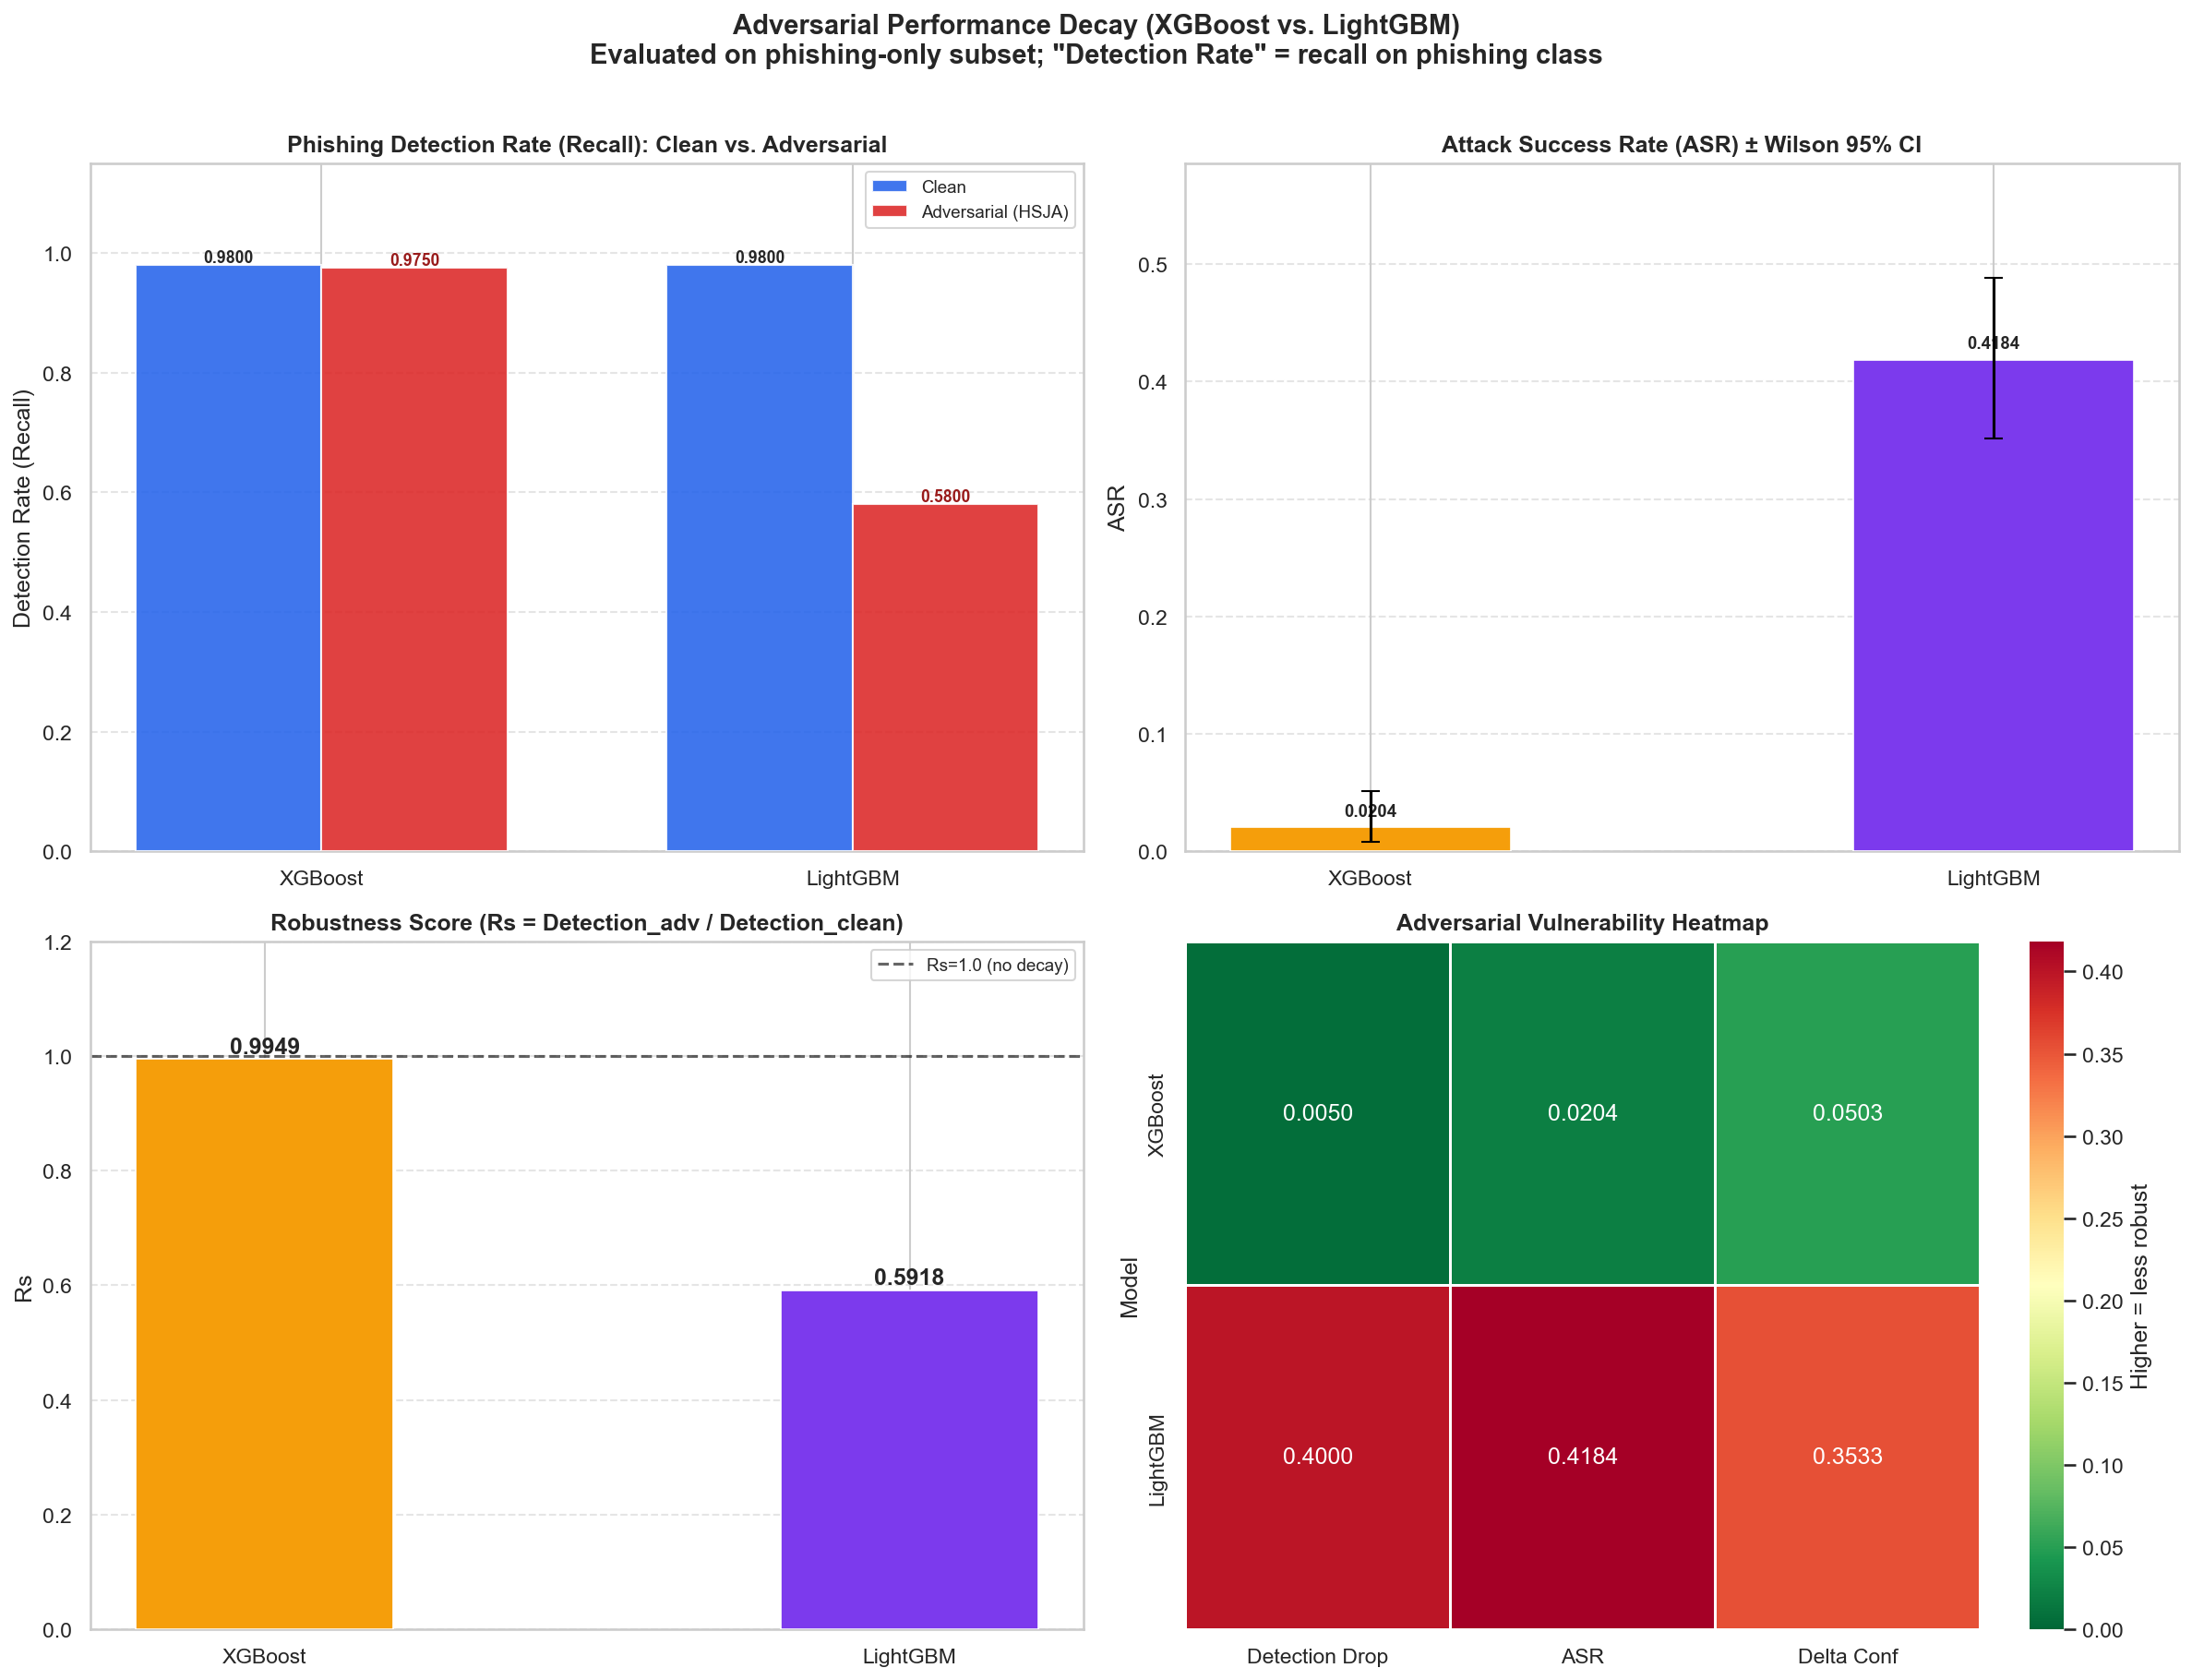


[CELL 4] Performance Decay selesai.


In [6]:
# ============================================================
#  CELL 4 — Performance Decay & Robustness Score
#  CATATAN VALIDITAS METRIK:
#    Evaluasi adversarial dilakukan pada subset HANYA-PHISHING
#    (y=1). Pada satu kelas, 'accuracy' == DETECTION RATE / RECALL
#    kelas phishing; F1 & ROC-AUC TIDAK terdefinisi pada satu kelas
#    sehingga TIDAK dilaporkan di sini. Metrik F1/AUC yang sah ada
#    di cv_summary (5-Fold pada test set seimbang).
# ============================================================

robustness_records = []

for model_name, model in final_models.items():
    X_adv_df     = adv_results[model_name]['X_adv']
    X_adv_np     = X_adv_df.to_numpy()
    evasion_mask = adv_results[model_name]['evasion_mask']
    asr          = adv_results[model_name]['ASR']
    asr_ci       = adv_results[model_name]['ASR_CI']

    pred_clean = model.predict(X_test_phish)
    pred_adv   = model.predict(X_adv_df)
    prob_clean = model.predict_proba(X_test_phish)[:, 1]
    prob_adv   = model.predict_proba(X_adv_df)[:, 1]

    # Detection rate (recall) kelas phishing — clean vs adversarial
    det_clean = float((pred_clean == 1).mean())
    det_adv   = float((pred_adv   == 1).mean())
    det_drop  = det_clean - det_adv

    # Robustness Score Rs = retensi deteksi = recall_adv / recall_clean
    Rs = det_adv / det_clean if det_clean > 0 else 0.0

    l2_all     = np.linalg.norm(X_adv_np - X_test_phish.to_numpy(), axis=1)
    n_evaded   = int(evasion_mask.sum())
    mean_l2    = l2_all[evasion_mask].mean() if n_evaded > 0 else 0.0
    delta_conf = float((prob_clean - prob_adv).mean())
    eps_norm   = mean_l2 / (X_test_phish.to_numpy().std() + 1e-8)
    ERS        = (1 - asr) / (1 + eps_norm)

    robustness_records.append({
        'Model'               : model_name,
        'Detection_Rate_Clean': round(det_clean, 4),
        'Detection_Rate_Adv'  : round(det_adv,   4),
        'Detection_Drop'      : round(det_drop,  4),
        'Robustness_Score'    : round(Rs,        4),
        'ASR'                 : round(asr,       4),
        'ASR_CI_low'          : round(asr_ci[0], 4),
        'ASR_CI_high'         : round(asr_ci[1], 4),
        'N_Evaded'            : n_evaded,
        'Mean_L2_Norm'        : round(mean_l2,   4),
        'Delta_Confidence'    : round(delta_conf, 4),
        'ERS'                 : round(ERS,        4),
    })

    note_l2 = '  (n kecil -> tidak stabil)' if 0 < n_evaded < 10 else ''
    print(f'\n[{model_name}] Robustness Metrics (subset phishing-only):')
    print(f'   Detection Rate : {det_clean:.4f} -> {det_adv:.4f}  (drop {det_drop:.4f})')
    print(f'   Robustness Rs  : {Rs:.4f}')
    print(f'   ASR            : {asr:.4f}  Wilson 95% CI=[{asr_ci[0]:.4f}, {asr_ci[1]:.4f}]')
    print(f'   Evaded samples : {n_evaded}/{len(X_test_phish)}')
    print(f'   Mean L2 (evaded): {mean_l2:.4f}{note_l2}')
    print(f'   Delta Conf     : {delta_conf:.4f}')
    print(f'   ERS            : {ERS:.4f}')

robustness_df = pd.DataFrame(robustness_records).set_index('Model')

print('\n\nROBUSTNESS COMPARISON TABLE (phishing-only subset):')
print(robustness_df.T.to_string())

# ── Visualisasi Performance Decay ────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Adversarial Performance Decay (XGBoost vs. LightGBM)\n'
    'Evaluated on phishing-only subset; "Detection Rate" = recall on phishing class',
    fontsize=14, fontweight='bold', y=1.01
)

model_names = robustness_df.index.tolist()
x_pos = np.arange(len(model_names))
bar_w = 0.35

# (1) Detection Rate: Clean vs Adversarial
ax1 = fig.add_subplot(2, 2, 1)
bars_c = ax1.bar(x_pos - bar_w/2, robustness_df['Detection_Rate_Clean'], bar_w,
                 label='Clean', color=COLOR_CLEAN, alpha=0.88, zorder=3)
bars_a = ax1.bar(x_pos + bar_w/2, robustness_df['Detection_Rate_Adv'], bar_w,
                 label='Adversarial (HSJA)', color=COLOR_ADV, alpha=0.88, zorder=3)
ax1.set_xticks(x_pos); ax1.set_xticklabels(model_names)
ax1.set_ylim(0, 1.15)
ax1.set_title('Phishing Detection Rate (Recall): Clean vs. Adversarial', fontweight='bold')
ax1.set_ylabel('Detection Rate (Recall)')
ax1.legend(fontsize=9)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)
for b in bars_c:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{b.get_height():.4f}', ha='center', fontsize=8.5, fontweight='bold')
for b in bars_a:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{b.get_height():.4f}', ha='center', fontsize=8.5, fontweight='bold', color='#991b1b')

# (2) Attack Success Rate (ASR) dengan Wilson 95% CI
ax2 = fig.add_subplot(2, 2, 2)
asr_vals = robustness_df['ASR'].values
ci_lo    = robustness_df['ASR_CI_low'].values
ci_hi    = robustness_df['ASR_CI_high'].values
yerr     = np.vstack([asr_vals - ci_lo, ci_hi - asr_vals])
bars_asr = ax2.bar(x_pos, asr_vals, 0.45,
                   color=[MODEL_COLORS[n] for n in model_names],
                   edgecolor='white', linewidth=0.8, zorder=3)
ax2.errorbar(x_pos, asr_vals, yerr=yerr, fmt='none',
             color='black', capsize=5, linewidth=1.5, zorder=4)
ax2.set_xticks(x_pos); ax2.set_xticklabels(model_names)
ax2.set_ylim(0, max(0.5, ci_hi.max()*1.2))
ax2.set_title('Attack Success Rate (ASR) ± Wilson 95% CI', fontweight='bold')
ax2.set_ylabel('ASR')
ax2.yaxis.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)
for b, v in zip(bars_asr, asr_vals):
    ax2.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.4f}',
             ha='center', fontsize=9, fontweight='bold')

# (3) Robustness Score Rs
ax3 = fig.add_subplot(2, 2, 3)
rs_vals = robustness_df['Robustness_Score'].values
bars_rs = ax3.bar(model_names, rs_vals,
                  color=[MODEL_COLORS[n] for n in model_names],
                  edgecolor='white', linewidth=0.8, zorder=3, width=0.4)
ax3.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Rs=1.0 (no decay)')
ax3.set_ylim(0, 1.2)
ax3.set_title('Robustness Score (Rs = Detection_adv / Detection_clean)', fontweight='bold')
ax3.set_ylabel('Rs')
ax3.legend(fontsize=9)
ax3.yaxis.grid(True, linestyle='--', alpha=0.5); ax3.set_axisbelow(True)
for b, v in zip(bars_rs, rs_vals):
    ax3.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')

# (4) Heatmap ringkas metrik adversarial
ax4 = fig.add_subplot(2, 2, 4)
heat_cols = ['Detection_Drop', 'ASR', 'Delta_Confidence']
heat_data = robustness_df[heat_cols].copy()
heat_data.columns = ['Detection Drop', 'ASR', 'Delta Conf']
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='RdYlGn_r',
            ax=ax4, linewidths=0.5, cbar_kws={'label': 'Higher = less robust'},
            vmin=0, vmax=max(0.35, heat_data.values.max()))
ax4.set_title('Adversarial Vulnerability Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()
print('\n[CELL 4] Performance Decay selesai.')


## Cell 5 — SHAP Analysis: Baseline vs. Adversarial Feature Importance Shift

In [7]:
# ============================================================
#  CELL 5 — SHAP Analysis: Feature Importance Shift
#  FIX BUG #5: Gunakan adv_results[name]['X_adv'] bukan
#  adversarial_data[name] (variable tidak pernah ada).
#  FIX BUG #7: X_phishing_np dicast ke float64 untuk SHAP.
#  Referensi: Lundberg & Lee (2017), NeurIPS.
#             Lundberg et al. (2020), Nature Machine Intelligence.
# ============================================================

np.random.seed(RANDOM_STATE)
n_shap   = min(SHAP_SAMPLE, len(X_test_phish))
shap_idx = np.random.choice(len(X_test_phish), n_shap, replace=False)
X_shap_clean = X_test_phish.iloc[shap_idx].reset_index(drop=True)

print(f'🔍 SHAP Analysis — {n_shap} sampel phishing...')

shap_results = {}

for name, model in final_models.items():
    print(f'\n  ─ [{name}] Computing SHAP values...')

    # FIX BUG #5: Gunakan adv_results bukan adversarial_data
    X_shap_adv = adv_results[name]['X_adv'].iloc[shap_idx].reset_index(drop=True)

    explainer = shap.TreeExplainer(model)

    sv_clean = explainer.shap_values(X_shap_clean)
    if isinstance(sv_clean, list):
        sv_clean = sv_clean[1]

    sv_adv = explainer.shap_values(X_shap_adv)
    if isinstance(sv_adv, list):
        sv_adv = sv_adv[1]

    fi_clean     = pd.Series(np.abs(sv_clean).mean(axis=0), index=FEATURE_COLS)
    fi_adv       = pd.Series(np.abs(sv_adv).mean(axis=0),   index=FEATURE_COLS)
    fi_shift     = fi_adv - fi_clean
    fi_shift_pct = (fi_shift / (fi_clean + 1e-9)) * 100

    shap_results[name] = {
        'sv_clean'    : sv_clean,
        'sv_adv'      : sv_adv,
        'fi_clean'    : fi_clean,
        'fi_adv'      : fi_adv,
        'fi_shift'    : fi_shift,
        'fi_shift_pct': fi_shift_pct,
        'X_shap_clean': X_shap_clean,
        'X_shap_adv'  : X_shap_adv,
    }

    top_shift = fi_shift.abs().nlargest(10)
    print(f'  Top 10 Feature Importance Shift ({name}):')
    for feat, val in top_shift.items():
        direction = '▲ +' if fi_shift[feat] > 0 else '▼ '
        pct       = fi_shift_pct[feat]
        print(f'    {feat:<35} {direction}{val:.5f}  ({pct:+.1f}%)')

print('\n✅ [CELL 5] SHAP values berhasil dikomputasi.')


🔍 SHAP Analysis — 200 sampel phishing...

  ─ [XGBoost] Computing SHAP values...
  Top 10 Feature Importance Shift (XGBoost):
    domain_in_title                     ▲ +0.53857  (+377.0%)
    page_rank                           ▼ 0.33854  (-22.1%)
    domain_registration_length          ▼ 0.12522  (-42.4%)
    nb_qm                               ▼ 0.08887  (-67.3%)
    nb_dots                             ▲ +0.07653  (+56.2%)
    domain_age                          ▼ 0.07445  (-25.2%)
    ratio_digits_host                   ▲ +0.06911  (+28.6%)
    phish_hints                         ▲ +0.05444  (+13.1%)
    domain_in_brand                     ▼ 0.05292  (-55.6%)
    google_index                        ▼ 0.04837  (-2.5%)

  ─ [LightGBM] Computing SHAP values...
  Top 10 Feature Importance Shift (LightGBM):
    page_rank                           ▼ 0.47919  (-19.4%)
    google_index                        ▲ +0.23448  (+8.1%)
    web_traffic                         ▲ +0.18113  (+35.8%)
  

## Cell 5B — Bootstrap Confidence Interval untuk SHAP Feature Importance


📊 [XGBoost] Bootstrap SHAP CI (n_boot=100)...
   ✅ Bootstrap CI selesai — Clean & Adversarial.

📊 [LightGBM] Bootstrap SHAP CI (n_boot=100)...
   ✅ Bootstrap CI selesai — Clean & Adversarial.


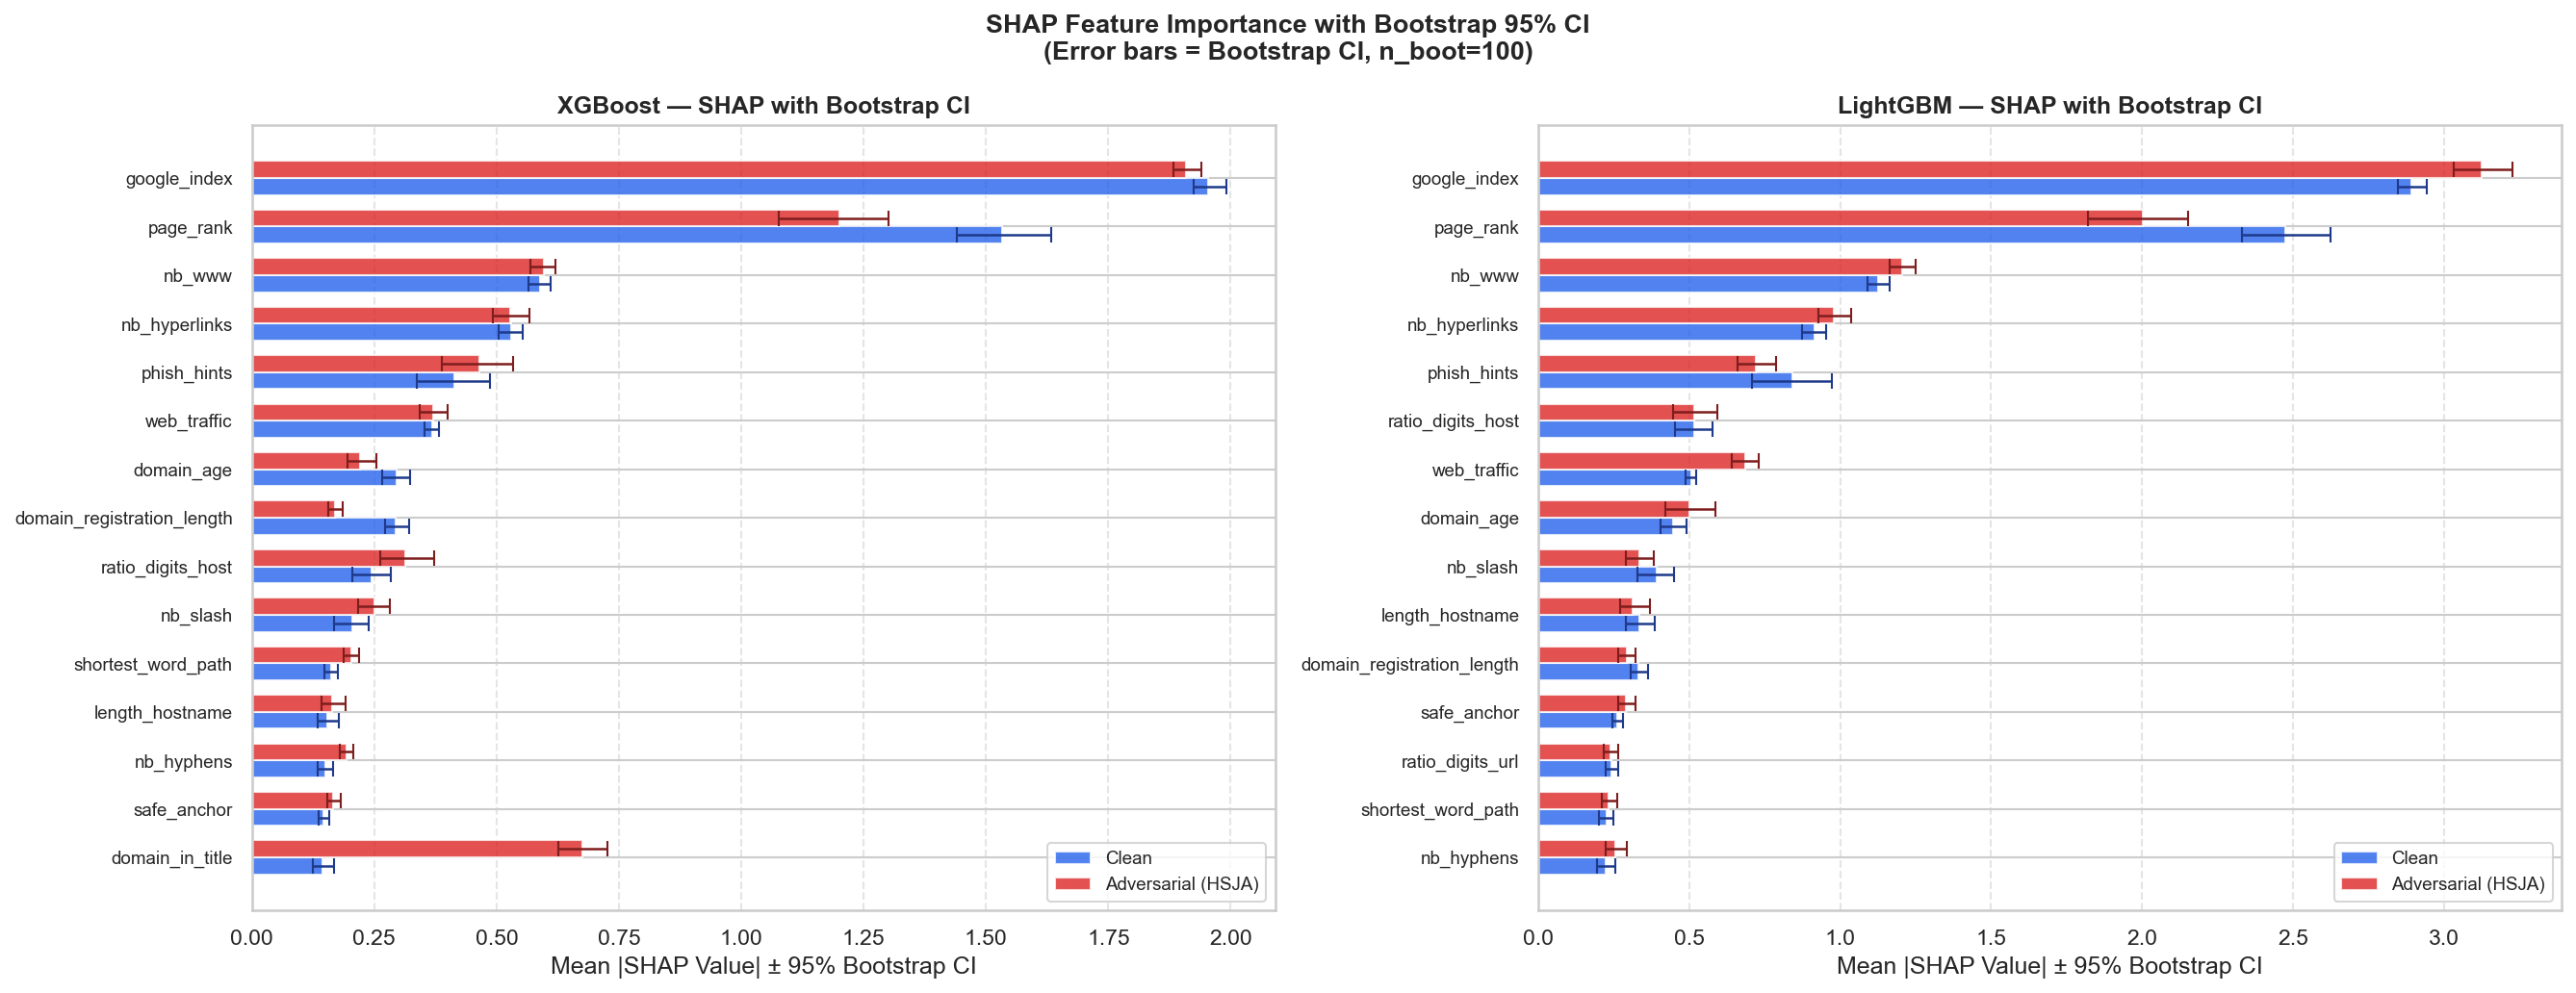

✅ [CELL 5B] Bootstrap SHAP CI selesai.


In [8]:
# ============================================================
#  CELL 5B — Bootstrap CI untuk SHAP Feature Importance

N_BOOTSTRAP  = 100   # Naikkan ke 200 untuk submission final
BOOTSTRAP_CI = 0.95

def compute_shap_bootstrap_ci(model, X_data_np, feature_names,
                               n_bootstrap=100, ci=0.95, seed=42):
    """
    Bootstrap Confidence Interval untuk mean |SHAP| per fitur.
    Prosedur: resample, hitung SHAP, ulangi, ambil percentile.
    """
    rng       = np.random.default_rng(seed)
    explainer = shap.TreeExplainer(model)
    n_samples = len(X_data_np)
    alpha_val = (1 - ci) / 2
    boot_means = np.zeros((n_bootstrap, len(feature_names)))

    for b in range(n_bootstrap):
        idx    = rng.choice(n_samples, size=n_samples, replace=True)
        X_boot = X_data_np[idx]
        sv     = explainer.shap_values(X_boot)
        if isinstance(sv, list):
            sv = sv[1]
        boot_means[b] = np.abs(sv).mean(axis=0)

    shap_mean = boot_means.mean(axis=0)
    ci_lower  = np.percentile(boot_means, alpha_val * 100,       axis=0)
    ci_upper  = np.percentile(boot_means, (1 - alpha_val) * 100, axis=0)
    return shap_mean, ci_lower, ci_upper


shap_bootstrap = {}

for model_name, model in final_models.items():
    n_s = min(SHAP_SAMPLE, len(X_test_phish))
    # FIX BUG #7: cast ke float64 untuk SHAP
    X_shap_np = X_test_phish.to_numpy()[:n_s].astype(np.float64)
    X_adv_np  = adv_results[model_name]['X_adv'].to_numpy()[:n_s].astype(np.float64)

    print(f'\n📊 [{model_name}] Bootstrap SHAP CI (n_boot={N_BOOTSTRAP})...')

    mean_cl, lo_cl, hi_cl = compute_shap_bootstrap_ci(
        model, X_shap_np, FEATURE_COLS, n_bootstrap=N_BOOTSTRAP
    )
    mean_ad, lo_ad, hi_ad = compute_shap_bootstrap_ci(
        model, X_adv_np,  FEATURE_COLS, n_bootstrap=N_BOOTSTRAP
    )

    shap_bootstrap[model_name] = {
        'clean': {'mean': mean_cl, 'lower': lo_cl, 'upper': hi_cl},
        'adv'  : {'mean': mean_ad, 'lower': lo_ad, 'upper': hi_ad},
    }
    print(f'   ✅ Bootstrap CI selesai — Clean & Adversarial.')


# ── Visualisasi: Top Features dengan Error Bar (Bootstrap CI) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'SHAP Feature Importance with Bootstrap 95% CI\n'
    f'(Error bars = Bootstrap CI, n_boot={N_BOOTSTRAP})',
    fontsize=13, fontweight='bold'
)

for ax, model_name in zip(axes, ['XGBoost', 'LightGBM']):
    bs = shap_bootstrap[model_name]
    cl = bs['clean']; ad = bs['adv']

    top_idx    = np.argsort(cl['mean'])[::-1][:TOP_N_FEAT]
    feat_names = [FEATURE_COLS[i] for i in top_idx]
    y_pos      = np.arange(len(top_idx))
    bar_h      = 0.35

    ax.barh(y_pos + bar_h/2,
            cl['mean'][top_idx], bar_h,
            xerr=[cl['mean'][top_idx] - cl['lower'][top_idx],
                  cl['upper'][top_idx] - cl['mean'][top_idx]],
            label='Clean', color=COLOR_CLEAN, alpha=0.8,
            error_kw=dict(elinewidth=1.2, capsize=4, ecolor='#1e3a8a'))

    ax.barh(y_pos - bar_h/2,
            ad['mean'][top_idx], bar_h,
            xerr=[ad['mean'][top_idx] - ad['lower'][top_idx],
                  ad['upper'][top_idx] - ad['mean'][top_idx]],
            label='Adversarial (HSJA)', color=COLOR_ADV, alpha=0.8,
            error_kw=dict(elinewidth=1.2, capsize=4, ecolor='#7f1d1d'))

    ax.set_yticks(y_pos)
    ax.set_yticklabels(feat_names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP Value| ± 95% Bootstrap CI')
    ax.set_title(f'{model_name} — SHAP with Bootstrap CI', fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print('✅ [CELL 5B] Bootstrap SHAP CI selesai.')


## Cell 6 — SHAP Visualization: Beeswarm & Feature Importance Shift


  📊 SHAP Visualization — XGBoost


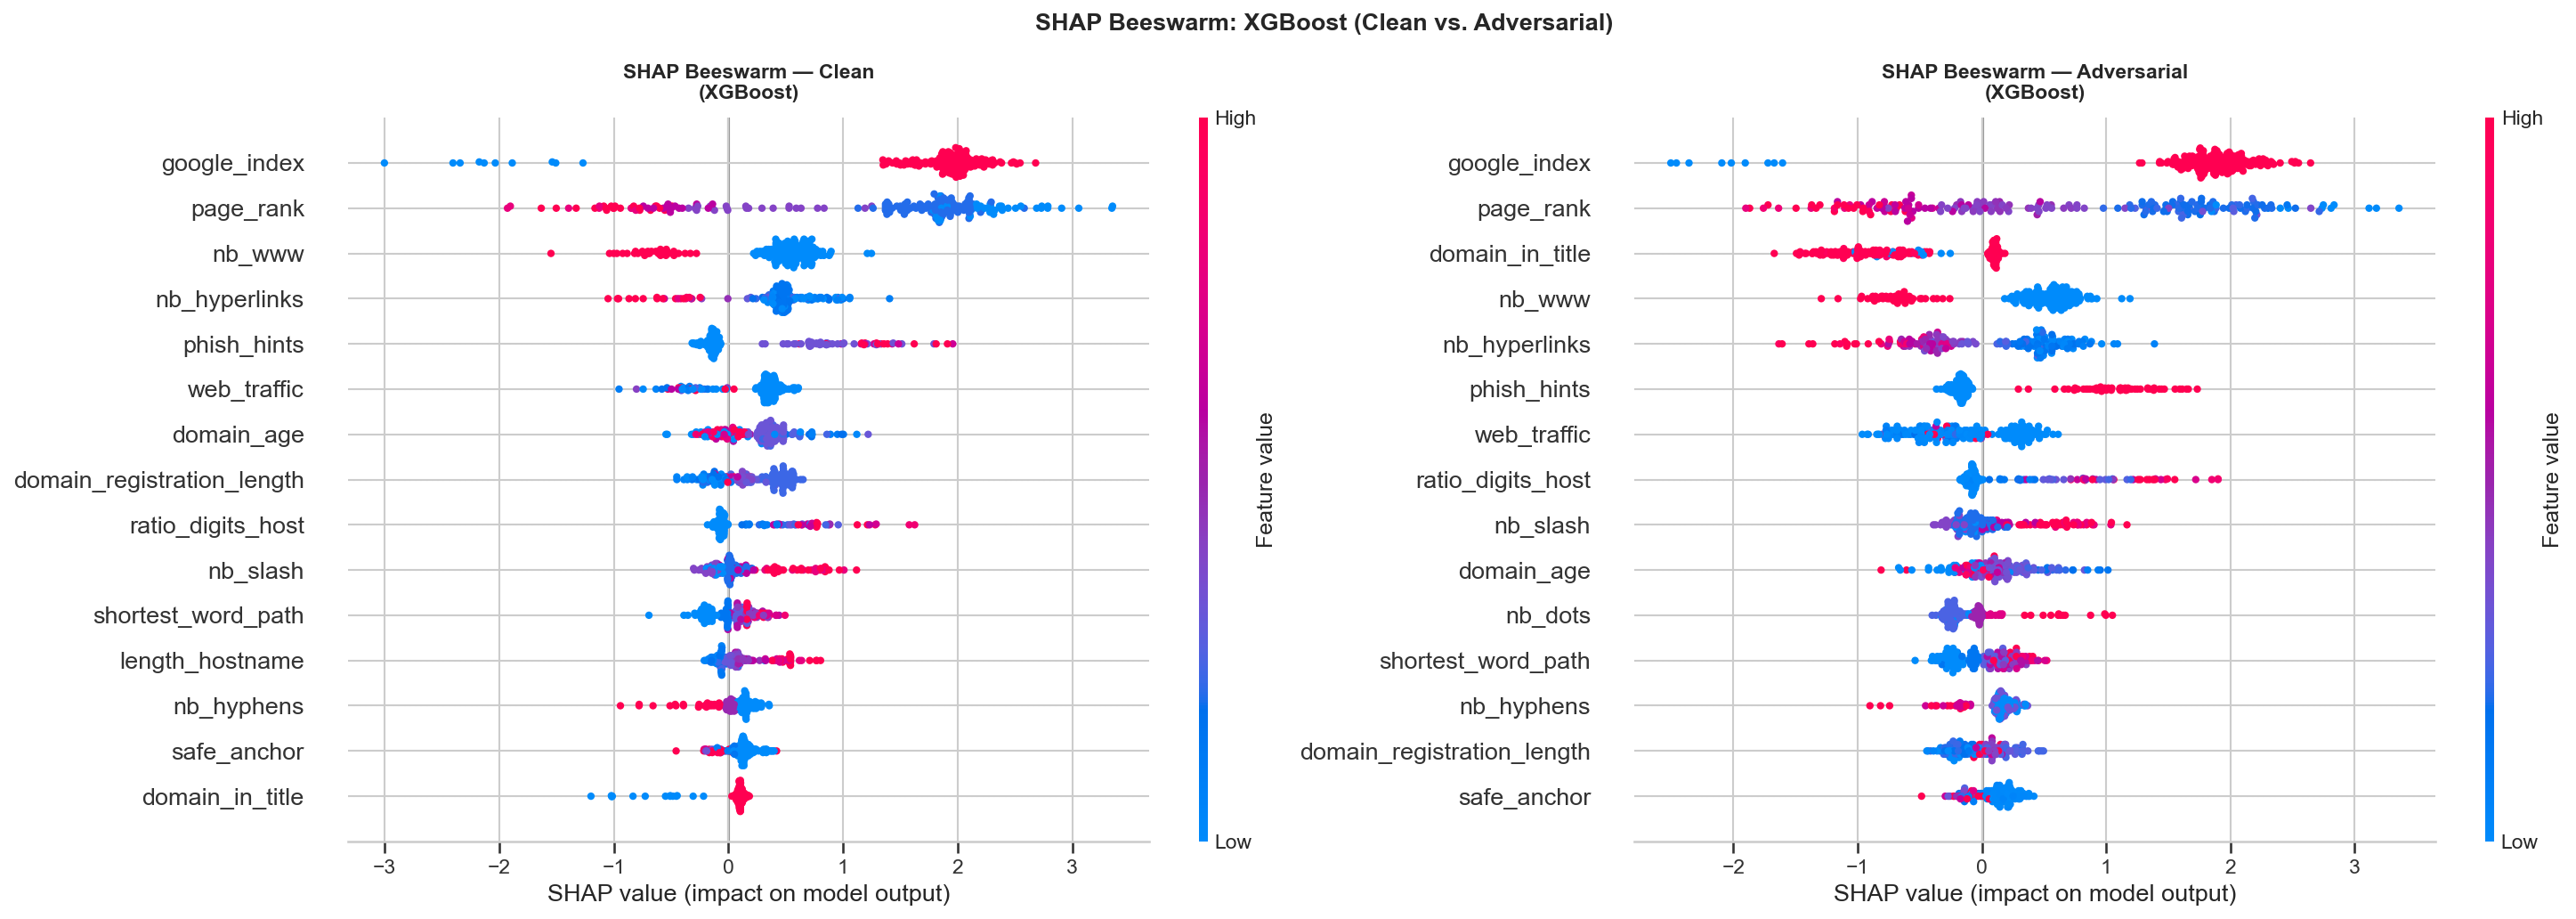

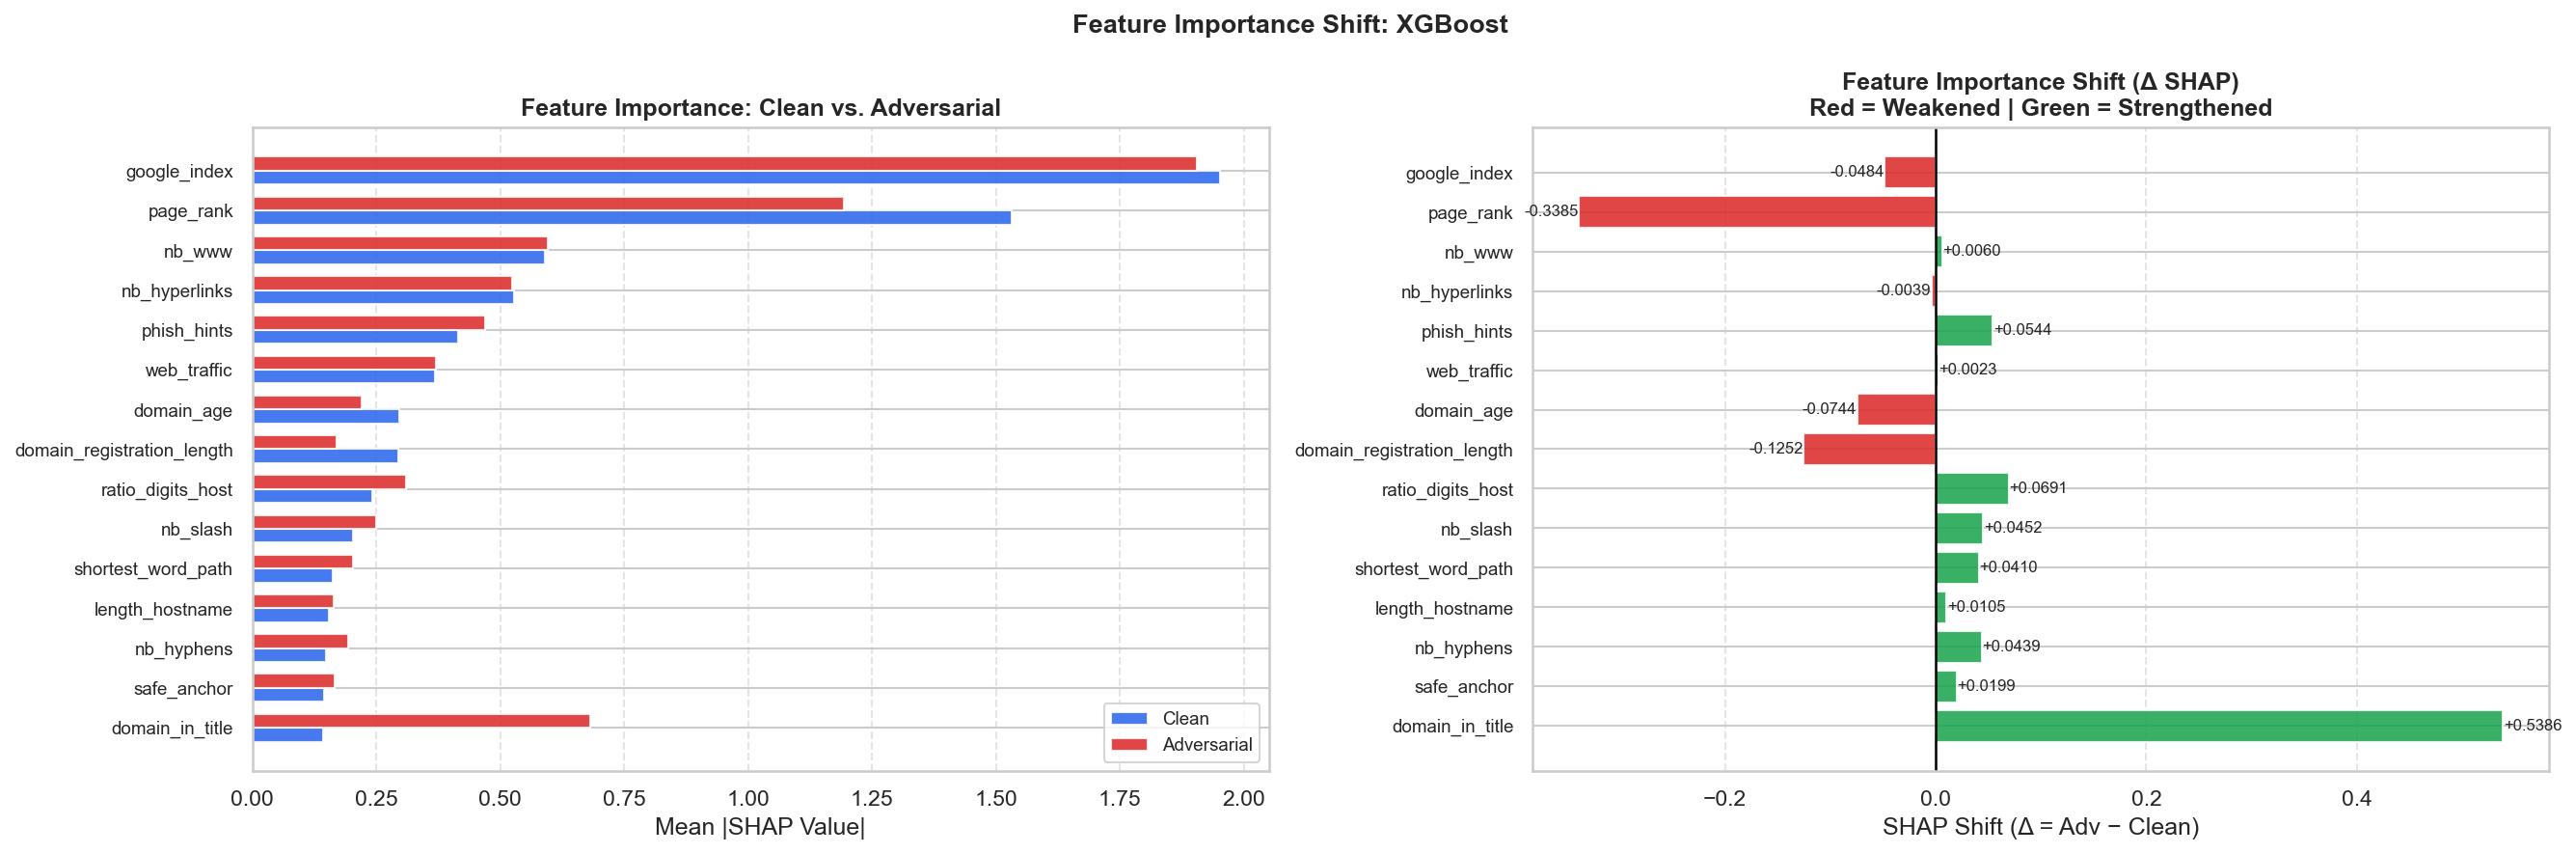


  📊 SHAP Visualization — LightGBM


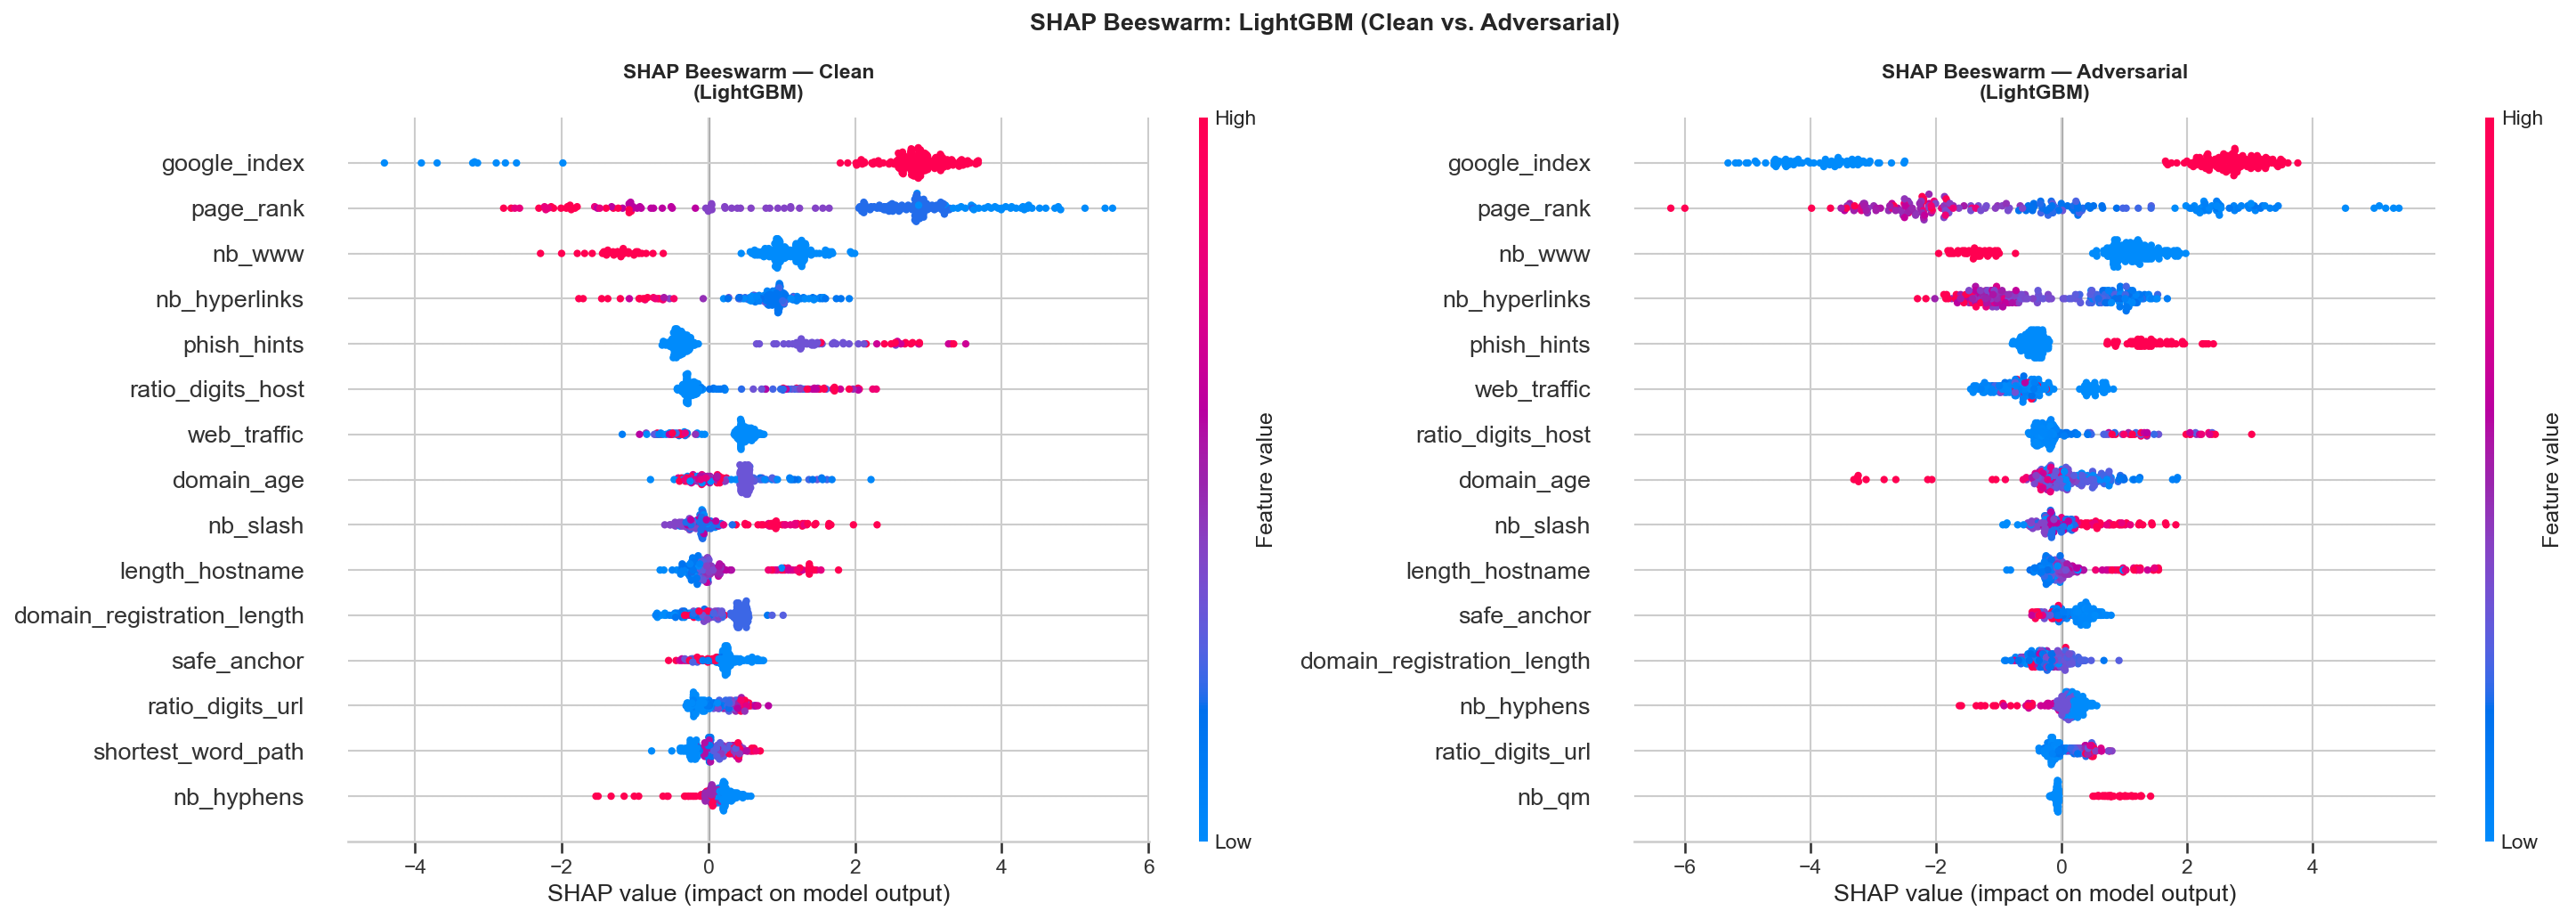

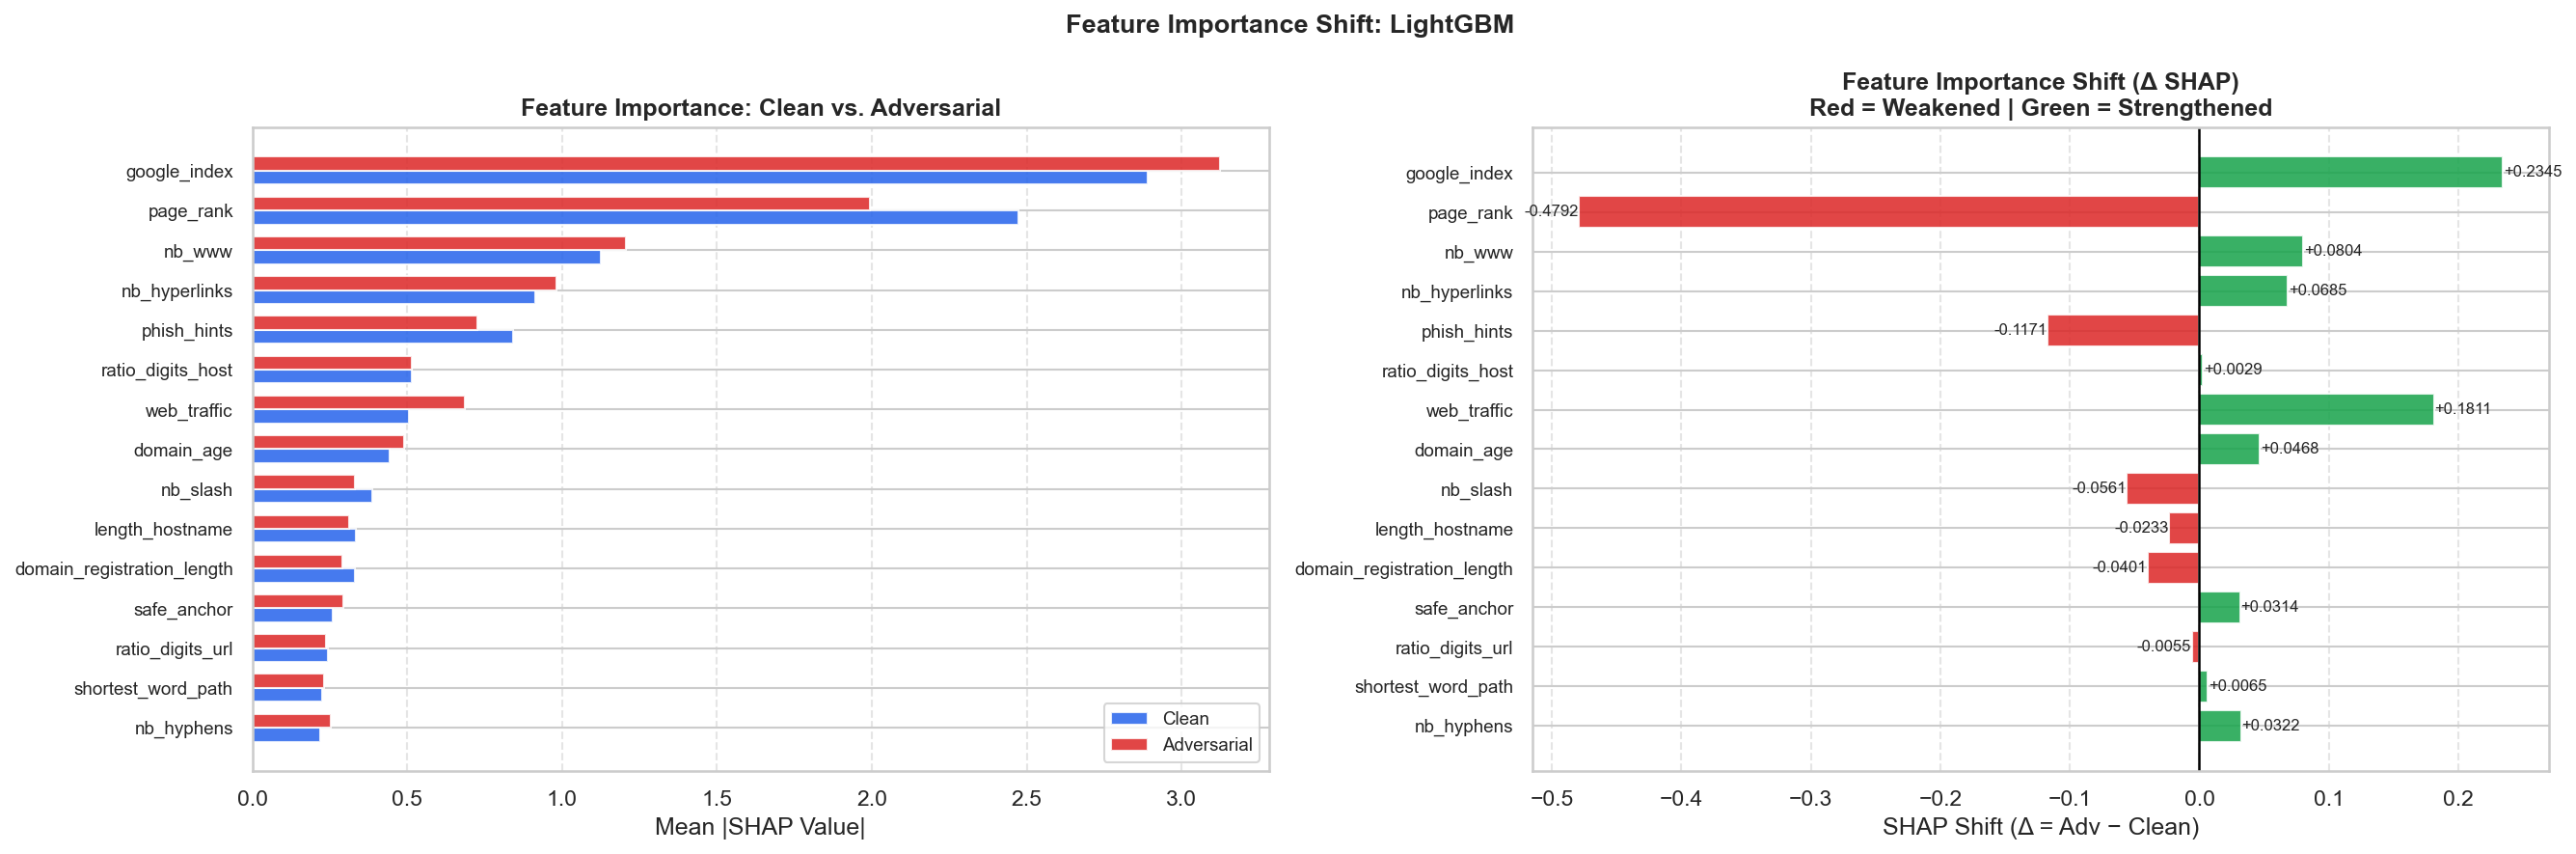


✅ [CELL 6] SHAP Visualization selesai.


In [9]:
# ============================================================
#  CELL 6 — SHAP Visualization: Beeswarm & Shift Bar Chart
# ============================================================

for model_name, shap_data in shap_results.items():
    print(f"\n{'='*65}")
    print(f"  📊 SHAP Visualization — {model_name}")
    print(f"{'='*65}")

    sv_clean = shap_data['sv_clean']
    sv_adv   = shap_data['sv_adv']
    X_cl     = shap_data['X_shap_clean']
    X_ad     = shap_data['X_shap_adv']
    fi_clean = shap_data['fi_clean']
    fi_adv   = shap_data['fi_adv']
    fi_shift = shap_data['fi_shift']

    # ── Beeswarm: Clean vs Adversarial ───────────────────────────────────────
    fig_a, axes_a = plt.subplots(1, 2, figsize=(20, 7))
    model_idx = list(shap_results.keys()).index(model_name)
    fig_a.suptitle(
        f'SHAP Beeswarm: {model_name} (Clean vs. Adversarial)',
        fontsize=13, fontweight='bold'
    )

    plt.sca(axes_a[0])
    shap.summary_plot(sv_clean, X_cl, feature_names=FEATURE_COLS,
                      max_display=TOP_N_FEAT, show=False, plot_size=None)
    axes_a[0].set_title(f'SHAP Beeswarm — Clean\n({model_name})',
                        fontsize=11, fontweight='bold', pad=10)

    plt.sca(axes_a[1])
    shap.summary_plot(sv_adv, X_ad, feature_names=FEATURE_COLS,
                      max_display=TOP_N_FEAT, show=False, plot_size=None)
    axes_a[1].set_title(f'SHAP Beeswarm — Adversarial\n({model_name})',
                        fontsize=11, fontweight='bold', pad=10)

    plt.tight_layout()
    plt.show()

    # ── Bar Chart: Feature Importance Shift ──────────────────────────────────
    top_feats    = fi_clean.nlargest(TOP_N_FEAT).index.tolist()
    fi_cl_top    = fi_clean[top_feats]
    fi_ad_top    = fi_adv[top_feats]
    fi_shift_top = fi_shift[top_feats]

    fig_b, axes_b = plt.subplots(1, 2, figsize=(18, 6))
    fig_b.suptitle(
        f'Feature Importance Shift: {model_name}',
        fontsize=13, fontweight='bold'
    )

    ax = axes_b[0]
    y_pos = np.arange(len(top_feats))
    bar_h = 0.35
    ax.barh(y_pos + bar_h/2, fi_cl_top.values, bar_h, label='Clean', color=COLOR_CLEAN, alpha=0.85)
    ax.barh(y_pos - bar_h/2, fi_ad_top.values, bar_h, label='Adversarial', color=COLOR_ADV, alpha=0.85)
    ax.set_yticks(y_pos); ax.set_yticklabels(top_feats, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title('Feature Importance: Clean vs. Adversarial', fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)

    ax = axes_b[1]
    shift_colors = [COLOR_ADV if v < 0 else '#16a34a' for v in fi_shift_top.values]
    bars_sh = ax.barh(y_pos, fi_shift_top.values, color=shift_colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_yticks(y_pos); ax.set_yticklabels(top_feats, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('SHAP Shift (Δ = Adv − Clean)')
    ax.set_title('Feature Importance Shift (Δ SHAP)\nRed = Weakened | Green = Strengthened',
                 fontweight='bold')
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    for b, v in zip(bars_sh, fi_shift_top.values):
        ha = 'right' if v < 0 else 'left'
        offset = -0.0005 if v < 0 else 0.0005
        ax.text(v + offset, b.get_y()+b.get_height()/2,
                f'{v:+.4f}', va='center', ha=ha, fontsize=8)

    plt.tight_layout()
    plt.show()

print('\n✅ [CELL 6] SHAP Visualization selesai.')


## Cell 7 — Weakness Detection: Vulnerability Profiling per Fitur


🔴 TOP VULNERABLE FEATURES — XGBoost:
                            SHAP_Clean  SHAP_Adversarial  SHAP_Shift   Shift_Pct         Direction
page_rank                      1.53141           1.19287    -0.33854  -22.106371  Attack Surface ⬇
google_index                   1.95314           1.90477    -0.04837   -2.476500  Attack Surface ⬇
domain_in_title                0.14285           0.68142     0.53857  377.008881            Gain ⬆
domain_registration_length     0.29538           0.17015    -0.12522  -42.395088  Attack Surface ⬇
phish_hints                    0.41521           0.46965     0.05444   13.111520            Gain ⬆
domain_age                     0.29580           0.22136    -0.07445  -25.167320  Attack Surface ⬇
ratio_digits_host              0.24172           0.31083     0.06911   28.592770            Gain ⬆
nb_qm                          0.13203           0.04316    -0.08887  -67.311996  Attack Surface ⬇
nb_dots                        0.13620           0.21273     0.07653   

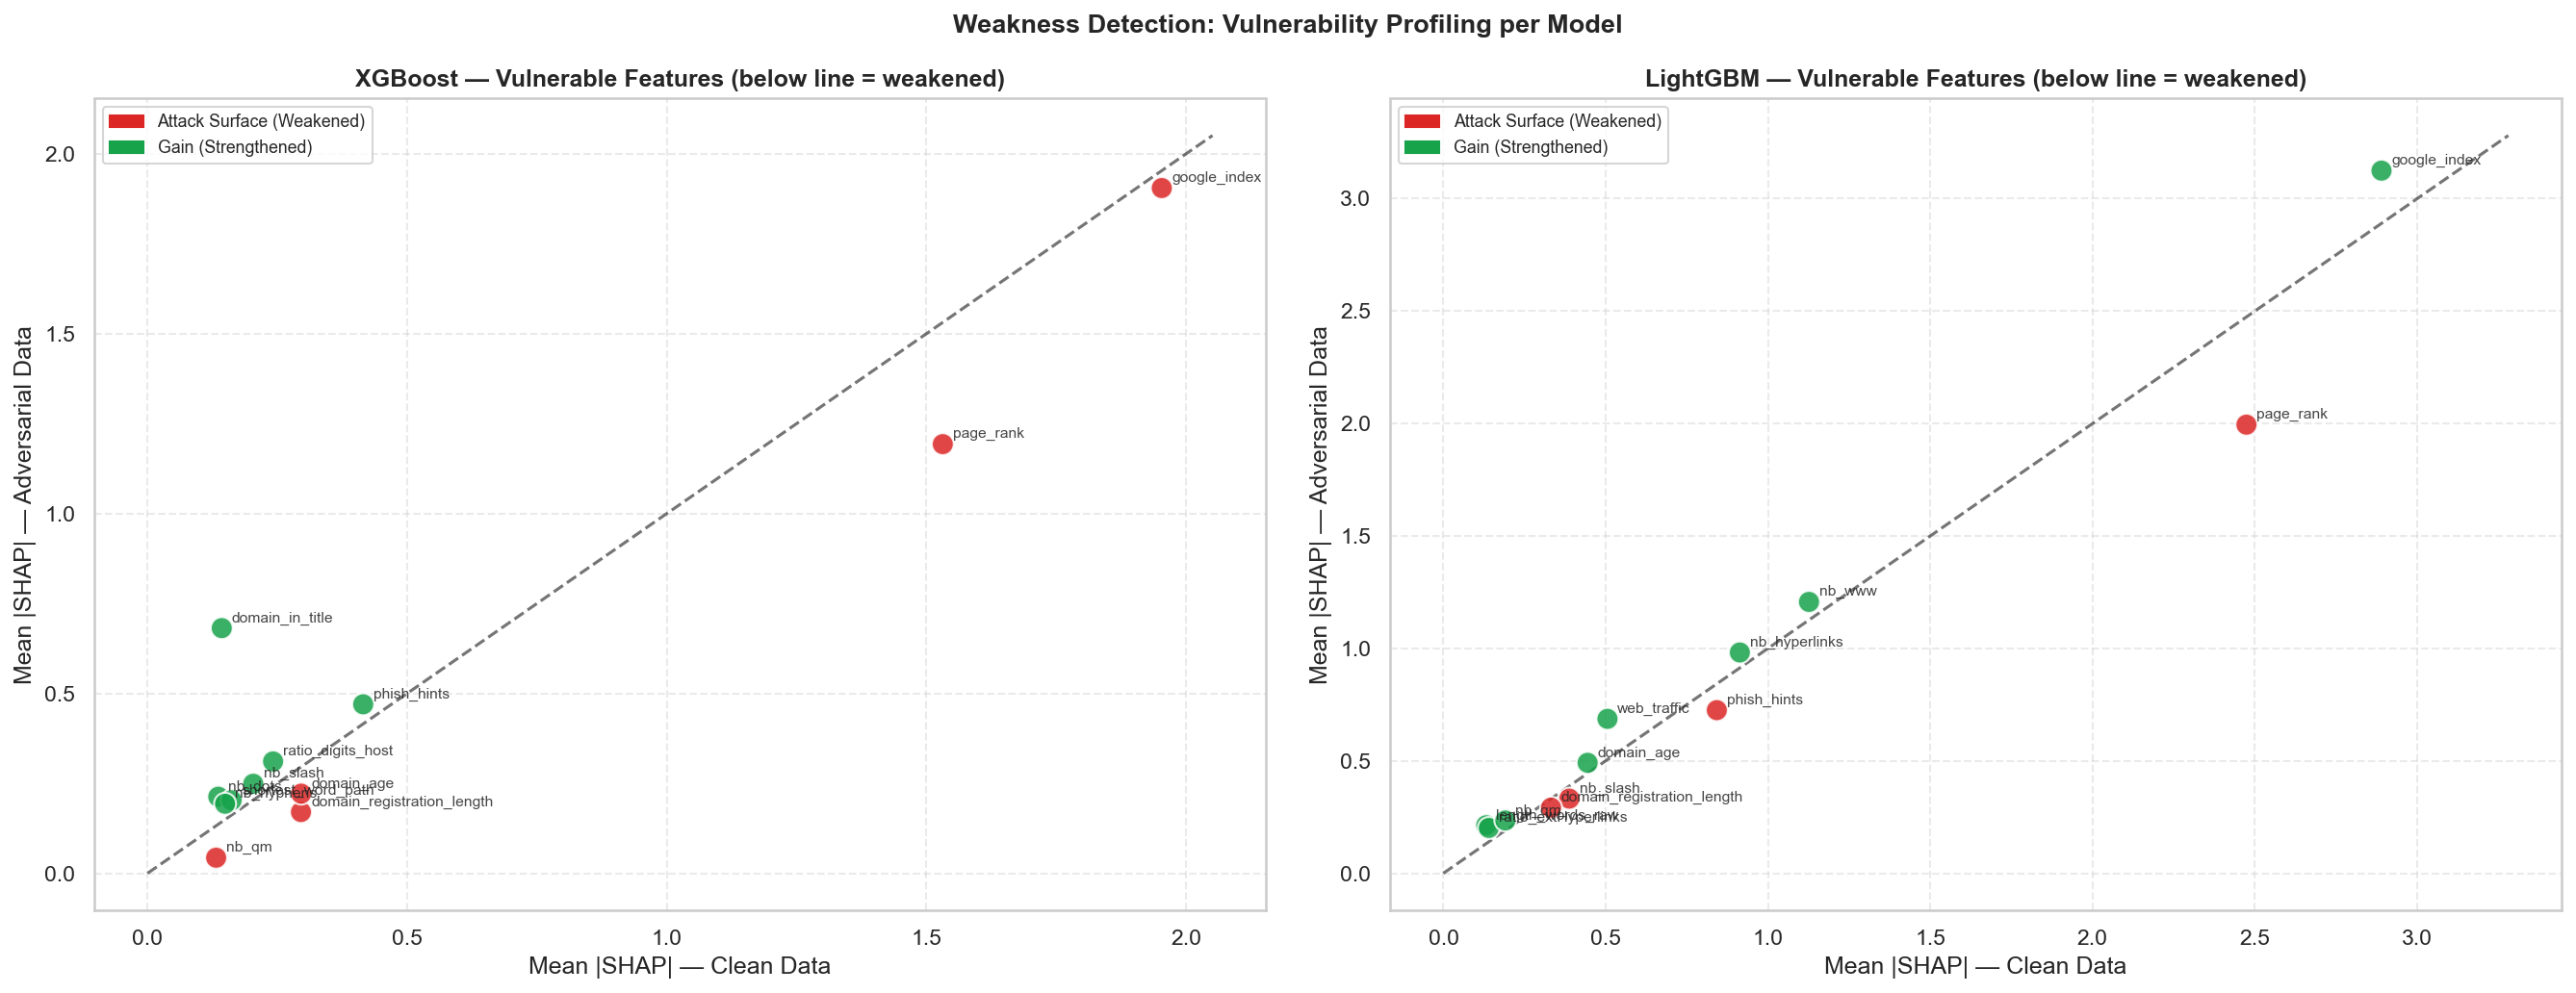

✅ [CELL 7] Weakness detection selesai.


In [10]:
# ============================================================
#  CELL 7 — Weakness Detection & Vulnerability Profiling
# ============================================================

def identify_vulnerable_features(shap_data, top_n=12):
    fi_clean   = shap_data['fi_clean']
    fi_shift   = shap_data['fi_shift']
    fi_shift_p = shap_data['fi_shift_pct']

    vuln_score = fi_clean * np.abs(fi_shift)
    direction  = fi_shift.apply(lambda x: 'Attack Surface ⬇' if x < 0 else 'Gain ⬆')

    vuln_df = pd.DataFrame({
        'SHAP_Clean'         : fi_clean,
        'SHAP_Adversarial'   : shap_data['fi_adv'],
        'SHAP_Shift'         : fi_shift,
        'Shift_Pct'          : fi_shift_p,
        'Vulnerability_Score': vuln_score,
        'Direction'          : direction,
    }).sort_values('Vulnerability_Score', ascending=False)

    return vuln_df.head(top_n)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Weakness Detection: Vulnerability Profiling per Model',
             fontsize=13, fontweight='bold')

all_vuln = {}
for idx, (model_name, shap_data) in enumerate(shap_results.items()):
    vuln_df = identify_vulnerable_features(shap_data, top_n=12)
    all_vuln[model_name] = vuln_df

    print(f'\n🔴 TOP VULNERABLE FEATURES — {model_name}:')
    print(vuln_df[['SHAP_Clean','SHAP_Adversarial','SHAP_Shift','Shift_Pct','Direction']]
          .round(5).to_string())

    ax = axes[idx]
    x_vals    = vuln_df['SHAP_Clean'].values
    y_vals    = vuln_df['SHAP_Adversarial'].values
    colors_v  = [COLOR_ADV if 'Surface' in d else '#16a34a'
                 for d in vuln_df['Direction'].values]

    ax.scatter(x_vals, y_vals, s=120, c=colors_v, alpha=0.85, edgecolors='white', zorder=3)
    diag_max = max(x_vals.max(), y_vals.max()) * 1.05
    ax.plot([0, diag_max], [0, diag_max], 'k--', linewidth=1.5, alpha=0.6, label='y=x (Stabil)')

    for feat, xv, yv in zip(vuln_df.index, x_vals, y_vals):
        ax.annotate(feat, (xv, yv), textcoords='offset points',
                    xytext=(5, 3), fontsize=7.5, alpha=0.85)

    ax.set_xlabel('Mean |SHAP| — Clean Data')
    ax.set_ylabel('Mean |SHAP| — Adversarial Data')
    ax.set_title(f'{model_name} — Vulnerable Features (below line = weakened)', fontweight='bold')

    patches = [
        mpatches.Patch(color=COLOR_ADV,   label='Attack Surface (Weakened)'),
        mpatches.Patch(color='#16a34a',   label='Gain (Strengthened)'),
    ]
    ax.legend(handles=patches, fontsize=8.5)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
print('✅ [CELL 7] Weakness detection selesai.')


## Cell 8 — Cross-Model Comparative Summary


COMPREHENSIVE ADVERSARIAL ROBUSTNESS SUMMARY:
Model                 XGBoost  LightGBM
CV_Mean_F1            0.97400   0.97680
CV_Std_F1             0.00280   0.00120
CV_Mean_AUC           0.99590   0.99620
Detection_Rate_Clean  0.98000   0.98000
Detection_Rate_Adv    0.97500   0.58000
Detection_Drop        0.00500   0.40000
Robustness_Score      0.99490   0.59180
ASR                   0.02040   0.41840
Mean_L2_Norm          6.20670   4.52870
Mean_SHAP_Shift       0.02169   0.02563


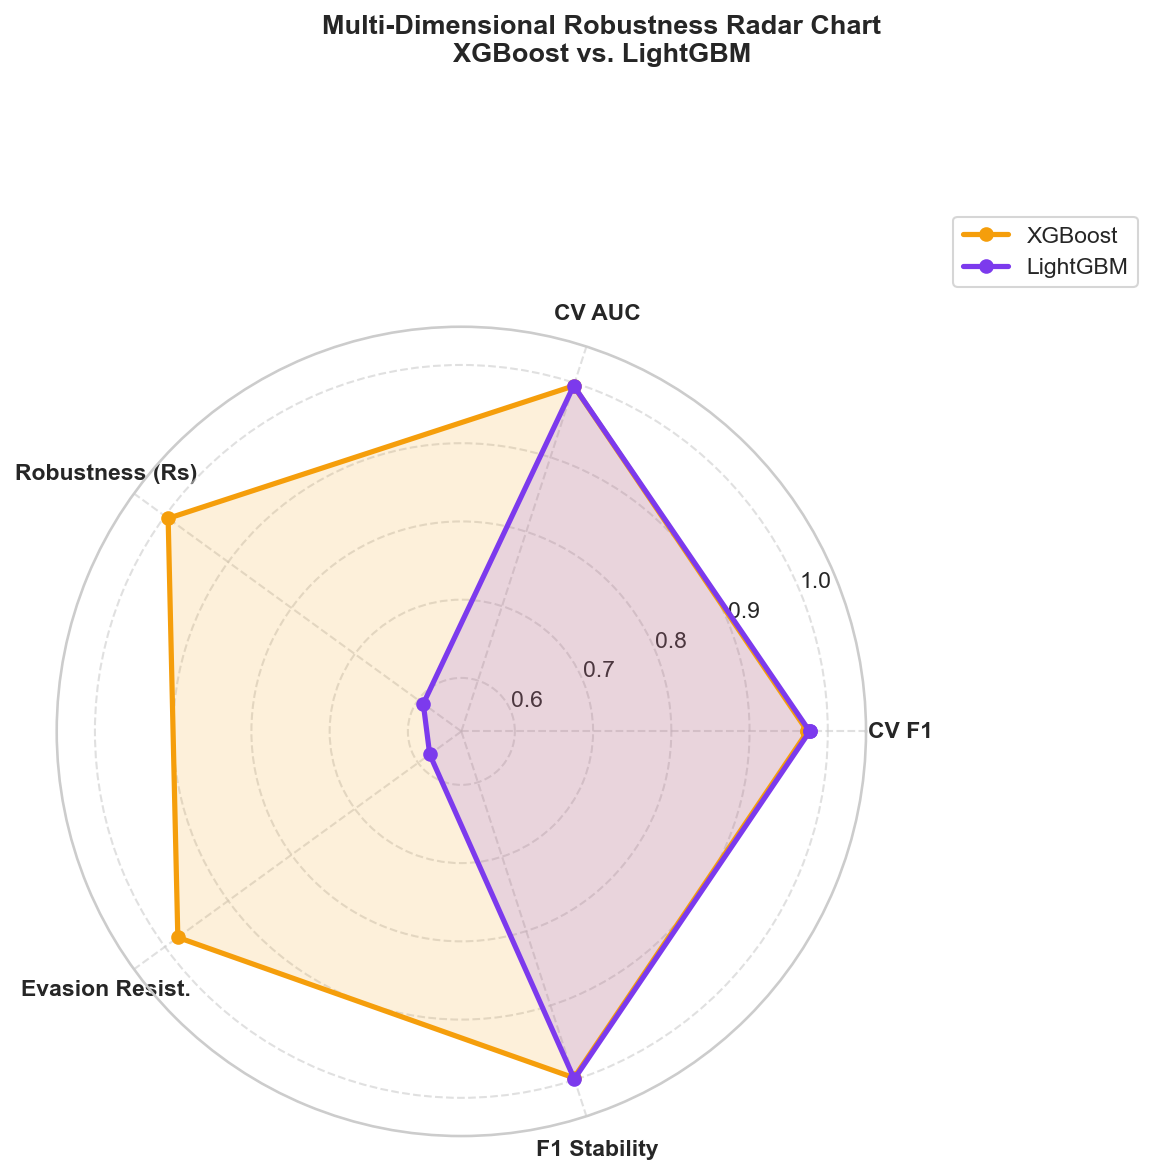

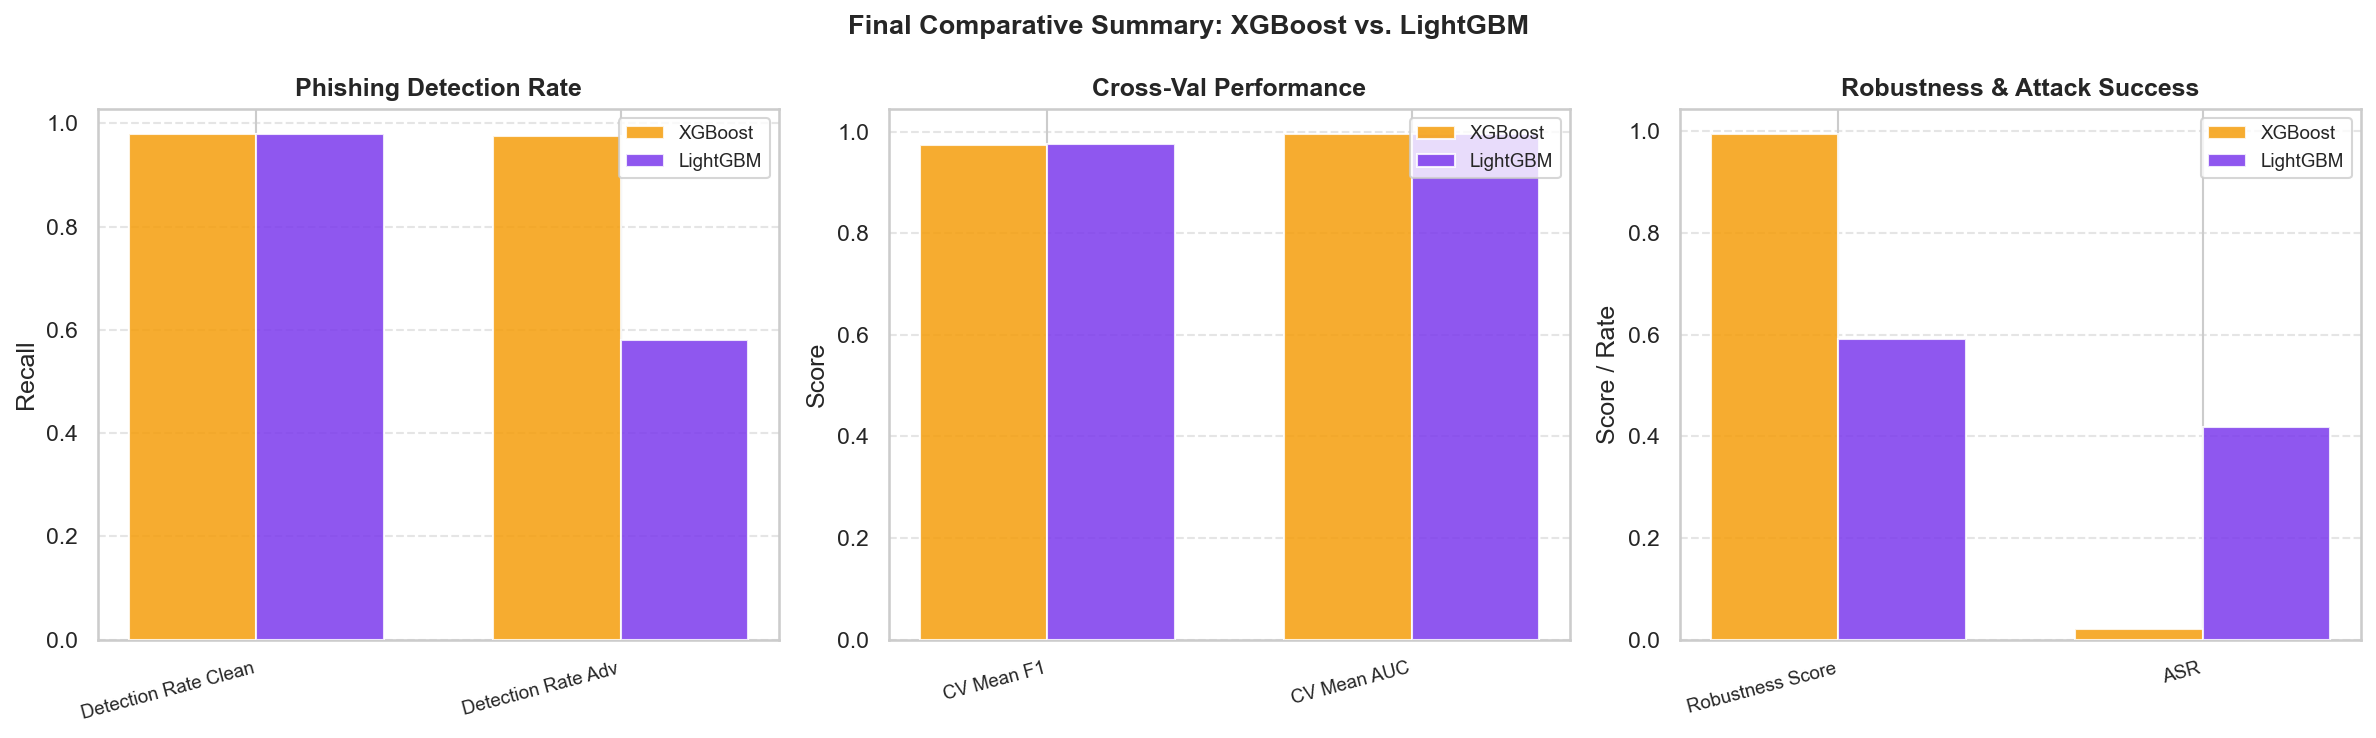

[CELL 8] Comparative summary selesai.


In [11]:
# ============================================================
#  CELL 8 — Cross-Model Comparative Summary
#  Menggabungkan: metrik baseline (CV F1/AUC pada test seimbang),
#  metrik adversarial (detection rate, Rs, ASR), dan SHAP shift.
# ============================================================

summary_data = []
for name in ['XGBoost', 'LightGBM']:
    row = robustness_df.loc[name].to_dict()
    row['Model']           = name
    row['Evasion_Rate']    = round(evasion_rates[name], 4)          # == ASR
    row['CV_Mean_F1']      = round(cv_summary[name]['Mean_F1'],  4)
    row['CV_Std_F1']       = round(cv_summary[name]['Std_F1'],   4)
    row['CV_Mean_AUC']     = round(cv_summary[name]['Mean_AUC'], 4)
    fi_shift               = shap_results[name]['fi_shift']
    row['Mean_SHAP_Shift'] = round(fi_shift.abs().mean(), 5)
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data).set_index('Model')

print('\nCOMPREHENSIVE ADVERSARIAL ROBUSTNESS SUMMARY:')
print('=' * 80)
key_cols = [
    'CV_Mean_F1', 'CV_Std_F1', 'CV_Mean_AUC',
    'Detection_Rate_Clean', 'Detection_Rate_Adv', 'Detection_Drop',
    'Robustness_Score', 'ASR', 'Mean_L2_Norm', 'Mean_SHAP_Shift',
]
print(summary_df[key_cols].T.to_string())
print('=' * 80)

# ── Radar Chart ───────────────────────────────────────────────────────────────
radar_metrics = {
    'CV F1'          : [cv_summary[n]['Mean_F1']                  for n in ['XGBoost', 'LightGBM']],
    'CV AUC'         : [cv_summary[n]['Mean_AUC']                 for n in ['XGBoost', 'LightGBM']],
    'Robustness (Rs)': [robustness_df.loc[n, 'Robustness_Score']  for n in ['XGBoost', 'LightGBM']],
    'Evasion Resist.': [1 - evasion_rates[n]                      for n in ['XGBoost', 'LightGBM']],
    'F1 Stability'   : [1 - cv_summary[n]['Std_F1']               for n in ['XGBoost', 'LightGBM']],
}

labels  = list(radar_metrics.keys())
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Multi-Dimensional Robustness Radar Chart\nXGBoost vs. LightGBM',
             fontsize=13, fontweight='bold', y=1.02)

all_vals = [v for vals in radar_metrics.values() for v in vals]
r_min = max(0, min(all_vals) - 0.05)
r_max = min(1.05, max(all_vals) + 0.05)

for i, (model_name, color) in enumerate(MODEL_COLORS.items()):
    values  = [radar_metrics[m][i] for m in labels]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(r_min, r_max)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ── Bar Chart Summary ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Final Comparative Summary: XGBoost vs. LightGBM',
             fontsize=13, fontweight='bold')

comparison_groups = [
    (['Detection_Rate_Clean', 'Detection_Rate_Adv'], 'Phishing Detection Rate', 'Recall'),
    (['CV_Mean_F1', 'CV_Mean_AUC'],                  'Cross-Val Performance',   'Score'),
    (['Robustness_Score', 'ASR'],                    'Robustness & Attack Success', 'Score / Rate'),
]

for ax, (cols, title, ylabel) in zip(axes, comparison_groups):
    xgb_vals = [summary_df.loc['XGBoost',  c] for c in cols]
    lgb_vals = [summary_df.loc['LightGBM', c] for c in cols]
    x_c      = np.arange(len(cols))
    w        = 0.35
    ax.bar(x_c - w/2, xgb_vals, w, label='XGBoost',  color=COLOR_XGB, alpha=0.85, zorder=3)
    ax.bar(x_c + w/2, lgb_vals, w, label='LightGBM', color=COLOR_LGB, alpha=0.85, zorder=3)
    ax.set_xticks(x_c)
    ax.set_xticklabels([c.replace('_', ' ') for c in cols], fontsize=9, rotation=15, ha='right')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
print('[CELL 8] Comparative summary selesai.')


## Cell 9 — Epsilon Sensitivity: Robustness Decay Curve



Robustness vs. L2 Perturbation Budget (post-hoc dari HSJA Cell 3)...
  Attack source : HopSkipJump (1 run, konsisten dengan Cell 3)
  eps           : L2 budget pada ruang ter-standardisasi (BUKAN param HSJA)

  L2 budget grid : [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 13.5, 20.0, 26.5, 33.0, 39.5, 46.0]
  (max L2 evasi teramati = 45.547)



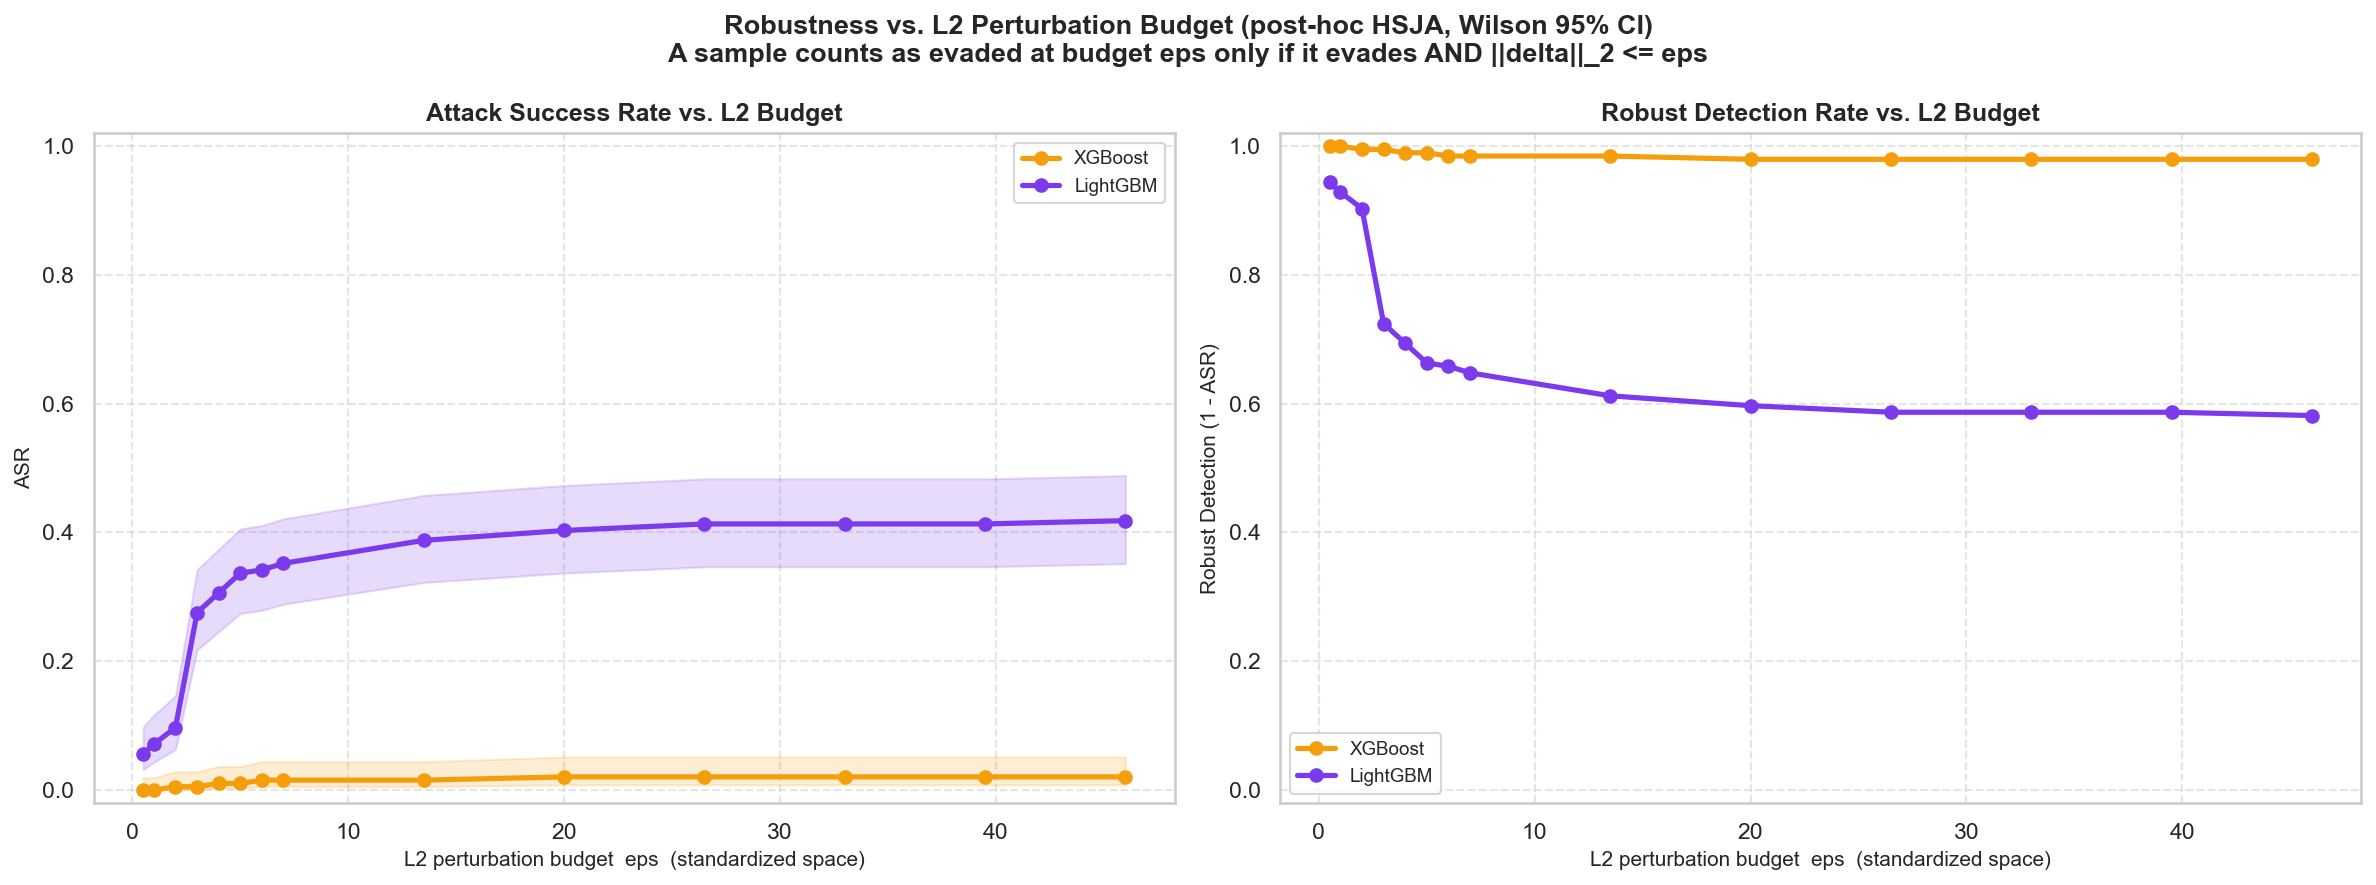


ROBUSTNESS-vs-BUDGET SUMMARY TABLE:
------------------------------------------------------------------------------
eps(L2)   Model        ASR        CI_lo      CI_hi      RobustDet 
------------------------------------------------------------------------------
0.50      XGBoost      0.0000     0.0000     0.0192     1.0000    
0.50      LightGBM     0.0561     0.0316     0.0977     0.9439    
1.00      XGBoost      0.0000     0.0000     0.0192     1.0000    
1.00      LightGBM     0.0714     0.0430     0.1163     0.9286    
2.00      XGBoost      0.0051     0.0009     0.0283     0.9949    
2.00      LightGBM     0.0969     0.0629     0.1464     0.9031    
3.00      XGBoost      0.0051     0.0009     0.0283     0.9949    
3.00      LightGBM     0.2755     0.2177     0.3419     0.7245    
4.00      XGBoost      0.0102     0.0028     0.0364     0.9898    
4.00      LightGBM     0.3061     0.2458     0.3739     0.6939    
5.00      XGBoost      0.0102     0.0028     0.0364     0.9898    
5

In [12]:
# ============================================================
#  CELL 9 — Robustness vs. L2 Perturbation Budget
#  PENTING: HopSkipJump TIDAK punya parameter epsilon (ia adalah
#  decision-boundary attack yang MEMINIMALKAN norm L2). Maka kurva
#  "robustness vs budget" dihitung POST-HOC dari SATU run HSJA
#  (Cell 3): sebuah adversarial example dihitung "berhasil dalam
#  budget eps" hanya jika ia evasif DAN ||delta||_2 <= eps.
#  Ini cara baku mengubah unbounded-L2 attack menjadi kurva
#  robust-accuracy-vs-budget (mis. Croce et al., 2021).
# ============================================================

print('Robustness vs. L2 Perturbation Budget (post-hoc dari HSJA Cell 3)...')
print(f'  Attack source : HopSkipJump (1 run, konsisten dengan Cell 3)')
print(f'  eps           : L2 budget pada ruang ter-standardisasi (BUKAN param HSJA)\n')

# ── Hitung L2 per-sampel & mask evasi dari hasil HSJA tunggal ────────────────
per_model     = {}
all_l2_evaded = []
for name, model in final_models.items():
    X_adv_df   = adv_results[name]['X_adv']
    pred_clean = model.predict(X_test_phish)
    pred_adv   = model.predict(X_adv_df)
    l2         = np.linalg.norm(X_adv_df.to_numpy() - X_test_phish.to_numpy(), axis=1)
    evaded     = (pred_clean.to_numpy() == 1) & (pred_adv.to_numpy() == 0) \
                 if hasattr(pred_clean, 'to_numpy') else (pred_clean == 1) & (pred_adv == 0)
    n_phish    = int((np.asarray(pred_clean) == 1).sum())
    per_model[name] = {'l2': l2, 'evaded': np.asarray(evaded), 'n_phish': n_phish}
    if per_model[name]['evaded'].any():
        all_l2_evaded.append(l2[per_model[name]['evaded']])

all_l2_evaded = np.concatenate(all_l2_evaded) if all_l2_evaded else np.array([])

# ── Grid budget: gabung grid statis (Cell 0) + cakupan L2 teramati ───────────
obs_max  = float(all_l2_evaded.max()) if all_l2_evaded.size else max(L2_BUDGET_GRID)
eps_max  = float(np.ceil(max(obs_max, max(L2_BUDGET_GRID))))
EPS_GRID = sorted(set(
    [round(e, 2) for e in L2_BUDGET_GRID] +
    [round(e, 2) for e in np.linspace(0.5, eps_max, 8)]
))
print(f'  L2 budget grid : {EPS_GRID}')
print(f'  (max L2 evasi teramati = {obs_max:.3f})\n')

# ── ASR(eps) = fraksi phishing yang evasif dengan ||delta||_2 <= eps ─────────
budget_results = {name: {'asr': [], 'ci_lo': [], 'ci_hi': [], 'robust_det': []}
                  for name in final_models}
for name in final_models:
    pm = per_model[name]
    for eps in EPS_GRID:
        success      = pm['evaded'] & (pm['l2'] <= eps)
        n_succ       = int(success.sum())
        asr_e, lo, hi = compute_asr_wilson_ci(n_succ, pm['n_phish'])
        budget_results[name]['asr'].append(asr_e)
        budget_results[name]['ci_lo'].append(lo)
        budget_results[name]['ci_hi'].append(hi)
        budget_results[name]['robust_det'].append(1.0 - asr_e)

# ── Plot: ASR(eps) & Robust Detection(eps) dengan Wilson CI ribbon ──────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Robustness vs. L2 Perturbation Budget (post-hoc HSJA, Wilson 95% CI)\n'
    'A sample counts as evaded at budget eps only if it evades AND ||delta||_2 <= eps',
    fontsize=13, fontweight='bold'
)

specs = [
    ('asr',        'Attack Success Rate vs. L2 Budget', 'ASR'),
    ('robust_det', 'Robust Detection Rate vs. L2 Budget', 'Robust Detection (1 - ASR)'),
]
for (key, title, ylabel), ax in zip(specs, axes):
    for model_name, color in MODEL_COLORS.items():
        y_vals = budget_results[model_name][key]
        ax.plot(EPS_GRID, y_vals, marker='o', linewidth=2.5,
                color=color, label=model_name, zorder=3)
        if key == 'asr':
            ax.fill_between(EPS_GRID,
                            budget_results[model_name]['ci_lo'],
                            budget_results[model_name]['ci_hi'],
                            alpha=0.18, color=color)
    ax.set_xlabel('L2 perturbation budget  eps  (standardized space)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ── Tabel Ringkasan ──────────────────────────────────────────────────────────
print('\nROBUSTNESS-vs-BUDGET SUMMARY TABLE:')
print('-' * 78)
print(f'{"eps(L2)":<9} {"Model":<12} {"ASR":<10} {"CI_lo":<10} {"CI_hi":<10} {"RobustDet":<10}')
print('-' * 78)
for i, eps in enumerate(EPS_GRID):
    for nm in final_models:
        r = budget_results[nm]
        print(f'{eps:<9.2f} {nm:<12} {r["asr"][i]:<10.4f} '
              f'{r["ci_lo"][i]:<10.4f} {r["ci_hi"][i]:<10.4f} {r["robust_det"][i]:<10.4f}')
print('-' * 78)
print('\n[CELL 9] Robustness vs. L2 Budget selesai.')


## Cell 10 — Save Models, Results & Final Report

In [13]:
# ============================================================
#  CELL 10 — Save Artefak Eksperimen
# ============================================================

with open('phishing_models_xgb_lgb.pkl', 'wb') as f:
    pickle.dump(final_models, f)
print('💾 Models tersimpan: phishing_models_xgb_lgb.pkl')

robustness_df.to_csv('robustness_results.csv')
summary_df.to_csv('summary_results.csv')
print('💾 Evaluasi tersimpan: robustness_results.csv, summary_results.csv')

for name in final_models:
    shift_export = pd.DataFrame({
        'feature'    : FEATURE_COLS,
        'shap_clean' : shap_results[name]['fi_clean'].values,
        'shap_adv'   : shap_results[name]['fi_adv'].values,
        'shap_shift' : shap_results[name]['fi_shift'].values,
        'shift_pct'  : shap_results[name]['fi_shift_pct'].values,
    }).sort_values('shap_clean', ascending=False)
    fname = f'shap_shift_{name.lower()}.csv'
    shift_export.to_csv(fname, index=False)
    print(f'💾 SHAP Shift tersimpan: {fname}')

# ── Final Report ──────────────────────────────────────────────────────────────
print('\n')
print('╔' + '═'*70 + '╗')
print('║{:^70}║'.format('FINAL RESEARCH REPORT SUMMARY'))
print('╠' + '═'*70 + '╣')
print('║{:<70}║'.format('  Adversarial Robustness Evaluation — Phishing URL Detection'))
print('╠' + '═'*70 + '╣')
print('║{:<70}║'.format(f'  Dataset : {DATA_PATH} ({df_raw.shape[0]:,} sampel)'))
print('║{:<70}║'.format(f'  Fitur   : {len(FEATURE_COLS)} fitur numerik'))
print('║{:<70}║'.format(f'  CV      : {N_FOLDS}-Fold Stratified | HSJA n={len(X_phishing_np)}'))
print('╠' + '═'*70 + '╣')
for name in ['XGBoost', 'LightGBM']:
    cv_f1  = cv_summary[name]['Mean_F1']
    cv_auc = cv_summary[name]['Mean_AUC']
    rs     = robustness_df.loc[name, 'Robustness_Score']
    er     = evasion_rates[name]
    dd     = robustness_df.loc[name, 'Detection_Drop']
    print('║{:<70}║'.format(f'  {name}:'))
    print('║{:<70}║'.format(f'    CV F1={cv_f1:.4f}  CV AUC={cv_auc:.4f}'))
    print('║{:<70}║'.format(f'    Rₛ={rs:.4f}  Evasion Rate={er:.2%}  ΔDetect={dd:.4f}'))
    print('╠' + '═'*70 + '╣')
print('║{:<70}║'.format('  Output Files:'))
print('║{:<70}║'.format('    phishing_models_xgb_lgb.pkl'))
print('║{:<70}║'.format('    robustness_results.csv | summary_results.csv'))
print('║{:<70}║'.format('    shap_shift_xgboost.csv | shap_shift_lightgbm.csv'))
print('╚' + '═'*70 + '╝')


💾 Models tersimpan: phishing_models_xgb_lgb.pkl
💾 Evaluasi tersimpan: robustness_results.csv, summary_results.csv
💾 SHAP Shift tersimpan: shap_shift_xgboost.csv
💾 SHAP Shift tersimpan: shap_shift_lightgbm.csv


╔══════════════════════════════════════════════════════════════════════╗
║                    FINAL RESEARCH REPORT SUMMARY                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Adversarial Robustness Evaluation — Phishing URL Detection          ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset : dataset_phishing_v2.csv (11,430 sampel)                   ║
║  Fitur   : 87 fitur numerik                                          ║
║  CV      : 5-Fold Stratified | HSJA n=200                            ║
╠══════════════════════════════════════════════════════════════════════╣
║  XGBoost:                                                            ║
║    CV F1=0.9740  CV AUC=0.9959                           